# BIBLIOTECAS

In [ ]:

# MANIPULAÇÃO
import pandas as pd
import numpy as np


# VISUALIZAÇÃO
import matplotlib.pyplot as plt
import seaborn as sns



# XAI


import shap



# SERIALIZAÇÃO / PIPELINES


import gzip
import pickle
import copy
import os



# PATHS


from pathlib import Path
from datetime import datetime



# MÉTRICAS


from sklearn.metrics import (

    confusion_matrix,
    ConfusionMatrixDisplay,

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

    classification_report

)



# UTILITÁRIOS


import warnings

warnings.filterwarnings(
    "ignore"
)



# REPRODUTIBILIDADE


RANDOM_STATE=42

np.random.seed(
    RANDOM_STATE
)

print(
    "Bibliotecas carregadas com sucesso."
)

print(
    "Suporte ativo:"
)

print(
    "✓ Binário"
)

print(
    "✓ Multiclasse (8 classes)"
)

print(
    "✓ SHAP"
)

print(
    "✓ FP/FN"
)

print(
    "✓ XAI completo"
)

Bibliotecas carregadas com sucesso.
Suporte ativo:
✓ Binário
✓ Multiclasse (8 classes)
✓ SHAP
✓ FP/FN
✓ XAI completo


# 2. CARREGAMENTO DOS DADOS

In [20]:

# CORREÇÃO PARA MODELOS ANTIGOS
def get_sampling_strategy(*args, **kwargs):

    return "auto"

# DIRETÓRIOS
PROJECT_ROOT=Path.cwd().parent

DATASET_DIR=(
    PROJECT_ROOT/
    "datasense"/
    "dataset"
)

RESULTS_DIR=(
    PROJECT_ROOT/
    "experiments"/
    "results"
)

EVAL_DIR=(
    PROJECT_ROOT/
    "experiments"/
    "evaluations"
)


print("="*60)
print("VERIFICAÇÃO")
print("="*60)

print(
    "Dataset:",
    DATASET_DIR.exists()
)

print(
    "Results:",
    RESULTS_DIR.exists()
)

print(
    "Evaluations:",
    EVAL_DIR.exists()
)

# CARREGA DATASET
print(
    "\nCarregando dataset..."
)

dataset=pd.read_parquet(

    DATASET_DIR/
    "datasense_full_test_1sec.parquet"

)

# LABELS
y_test_binary=dataset[
    "label1"
].copy()

y_test_multi=dataset[
    "label4"
].copy()

# REMOVE TODOS LABELS

label_cols=[

    col

    for col in dataset.columns

    if col.startswith(
        "label"
    )

]

print(
    "\nLabels removidos:"
)

print(
    label_cols
)


X_test=dataset.drop(

    columns=label_cols,

    errors="ignore"

)


print(
    "\nDataset carregado:"
)

print(
    X_test.shape
)

# MODELOS BINÁRIOS
MODEL_PATHS_BINARY={

"logistic_regression":

RESULTS_DIR/
"logistic_regression_full_all"/
"pipe.pickle.gz",


"decision_tree":

RESULTS_DIR/
"decision_tree_full_all"/
"pipe.pickle.gz",


"random_forest":

RESULTS_DIR/
"random_forest_full_all"/
"pipe.pickle.gz"

}


MODELS_BINARY={}

print(
    "\nCarregando modelos binários..."
)

for name,path in MODEL_PATHS_BINARY.items():

    try:

        with gzip.open(
            path,
            "rb"
        ) as f:

            MODELS_BINARY[
                name
            ]=pickle.load(
                f
            )

        print(
            f"[OK] {name}"
        )

    except Exception as e:

        print(
            f"[ERRO] {name}"
        )

        print(e)


# MODELOS MULTICLASSE
MODEL_PATHS_MULTI={

"logistic_regression_multi":

RESULTS_DIR/
"logistic_regression_full_grouped"/
"pipe.pickle.gz",


"decision_tree_multi":

RESULTS_DIR/
"decision_tree_full_grouped"/
"pipe.pickle.gz",


"random_forest_multi":

RESULTS_DIR/
"random_forest_full_grouped"/
"pipe.pickle.gz"

}


MODELS_MULTI={}

print(
    "\nCarregando modelos multiclasses..."
)

for name,path in MODEL_PATHS_MULTI.items():

    try:

        with gzip.open(
            path,
            "rb"
        ) as f:

            MODELS_MULTI[
                name
            ]=pickle.load(
                f
            )

        print(
            f"[OK] {name}"
        )

    except Exception as e:

        print(
            f"[ERRO] {name}"
        )

        print(e)

# FEATURE ALIGNMENT
if len(MODELS_MULTI)>0:

    ref_model=list(
        MODELS_MULTI.values()
    )[0]

else:

    ref_model=list(
        MODELS_BINARY.values()
    )[0]


if hasattr(
    ref_model,
    "named_steps"
):

    try:

        expected_features=(

            ref_model
            .named_steps[
                "preprocessor"
            ]
            .get_feature_names_out()

        )

    except:

        expected_features=(
            X_test.columns
        )

else:

    expected_features=(
        X_test.columns
    )


X_test=X_test.reindex(

    columns=
    expected_features,

    fill_value=0

)


print("\n")
print("="*60)

print(
    "Dataset alinhado:",
    X_test.shape
)

print("="*60)


print(
    "\nClasses multiclasses:"
)

print(
    y_test_multi.value_counts()
)


print(
    "\nModelos binários:"
)

print(
    list(
        MODELS_BINARY.keys()
    )
)

print(
    "\nModelos multiclasses:"
)

print(
    list(
        MODELS_MULTI.keys()
    )
)

VERIFICAÇÃO
Dataset: True
Results: True
Evaluations: True

Carregando dataset...

Labels removidos:
['label1', 'label2', 'label3', 'label4', 'label_extended']

Dataset carregado:
(56798, 106)

Carregando modelos binários...
[OK] logistic_regression
[OK] decision_tree
[OK] random_forest

Carregando modelos multiclasses...
[OK] logistic_regression_multi
[OK] decision_tree_multi
[OK] random_forest_multi


Dataset alinhado: (56798, 106)

Classes multiclasses:
label4
benign                          34200
mitm_arp-spoofing                1048
malware_mirai-udp-flood          1004
recon_os-scan                     999
recon_host-disc-tcp-ack-ping      995
                                ...  
dos_mqtt-publish-flood             15
dos_slowloris-port-1883            15
dos_slowloris-port-554             15
dos_slowloris-port-8000            15
dos_syn-flood-port-557              8
Name: count, Length: 84, dtype: int64

Modelos binários:
['logistic_regression', 'decision_tree', 'random_forest']


In [21]:

# OBJETIVO:
#
# Carregar:
#
# 1) Dataset de teste
# 2) Modelos treinados
# 3) Resultados do evaluations
#
# JUSTIFICATIVA:
#
# O dataset é usado para SHAP
#
# Os modelos são necessários
# para calcular explicabilidade
#
# O evaluations fornece:
#
# métricas
# confusion matrices
# PCA
# t-SNE
#



PROJECT_ROOT=Path.cwd().parent


# ------------------------------------------------
# Caminhos reais do projeto
# ------------------------------------------------

DATASET_DIR=PROJECT_ROOT/"datasense"/"dataset"

RESULTS_DIR=PROJECT_ROOT/"experiments"/"results"

EVAL_DIR=PROJECT_ROOT/"experiments"/"evaluations"


print("="*60)

print("VERIFICAÇÃO")

print("="*60)

print("\nDataset:",DATASET_DIR.exists())

print("Results:",RESULTS_DIR.exists())

print("Evaluations:",EVAL_DIR.exists())


# ------------------------------------------------
# Carregar Dataset
# ------------------------------------------------

X_test=pd.read_parquet(

DATASET_DIR/
"datasense_full_test_1sec.parquet"

)


y_test=X_test["label4"].copy()


X_test=X_test.drop(

columns=[

"label1",
"label2",
"label4"

],

errors="ignore"

)

print("\nDataset:")

print(X_test.shape)



# ------------------------------------------------
# Carregar modelos
# ------------------------------------------------

MODELS={}


MODEL_PATHS={

"logistic_regression":

RESULTS_DIR/
"logistic_regression_full_all"/
"pipe.pickle.gz",


"decision_tree":

RESULTS_DIR/
"decision_tree_full_all"/
"pipe.pickle.gz",


"random_forest":

RESULTS_DIR/
"random_forest_full_all"/
"pipe.pickle.gz"

}



for name,path in MODEL_PATHS.items():

    print("\nCarregando:",name)

    with gzip.open(

    path,
    "rb"

    ) as f:

        MODELS[name]=pickle.load(
        f
        )


print("\nModelos carregados:")

print(MODELS.keys())


# ------------------------------------------------
# Carregar Feature Importance
# ------------------------------------------------

feature_importance=pd.read_csv(

EVAL_DIR/
"feature_importances.csv"

)

print("\nFeature importance carregado")

display(

feature_importance.head()

)

VERIFICAÇÃO

Dataset: True
Results: True
Evaluations: True

Dataset:
(56798, 108)

Carregando: logistic_regression

Carregando: decision_tree

Carregando: random_forest

Modelos carregados:
dict_keys(['logistic_regression', 'decision_tree', 'random_forest'])

Feature importance carregado


,feature,binary_decision_tree_importance,binary_logistic_regression_importance,binary_random_forest_importance,binary_avg_importance,grouped_decision_tree_importance,grouped_logistic_regression_importance,grouped_random_forest_importance,grouped_avg_importance,all_decision_tree_importance,all_logistic_regression_importance,all_random_forest_importance,all_avg_importance,total_avg,total_avg_scaled
0,network_packets_dst_count,0.001600,0.000000,0.256204,0.257804,0.365503,0.000000,0.364834,0.730337,0.217147,0.000000,0.303023,0.520170,0.502770,1.000000
1,network_ports_src_count,0.000027,0.317851,0.071568,0.389446,0.001183,0.269663,0.099002,0.369848,0.008798,0.283226,0.236538,0.528563,0.429285,0.853712
2,network_tcp-flags-syn_count,0.000000,0.310405,0.017102,0.327506,0.000965,0.156229,0.067596,0.224790,0.178240,0.205119,0.198926,0.582286,0.378194,0.752003
3,network_packets_all_count,0.340651,0.000000,0.314262,0.654913,0.008613,0.000000,0.290095,0.298708,0.011440,0.000000,0.168252,0.179693,0.377771,0.751161
4,device_type_iot,0.000000,0.022722,0.002605,0.025327,0.292649,0.242302,0.327078,0.862028,0.062995,0.092260,0.068500,0.223755,0.370370,0.736427


# 3. FEATURE IMPORTANCE + TOP FEATURES

In [22]:
feature_importance = pd.read_csv(
    EVAL_DIR / "feature_importances.csv"
)

feature_col = "feature"
importance_col = "binary_avg_importance"

TOP_N = 20

top_features = (
    feature_importance
    .sort_values(by=importance_col, ascending=False)
    .head(TOP_N)
)

selected_features = top_features[feature_col].tolist()

valid_features = [f for f in selected_features if f in X_test.columns]

X_xai = X_test[valid_features]

print("XAI dataset:", X_xai.shape)

XAI dataset: (56798, 20)


# 4. SHAP GLOBAL

In [23]:
def shap_global(values):
    values = np.array(values)

    if isinstance(values, list):
        values = values[1]

    return np.mean(np.abs(values), axis=0)


def get_shap(model, X_sample, name):

    # ---------------- TREE MODELS ----------------
    if "tree" in name or "forest" in name:

        if hasattr(model, "named_steps"):
            pre = model[:-1]
            final_model = model[-1]
            X_trans = pre.transform(X_sample)
        else:
            final_model = model
            X_trans = X_sample

        explainer = shap.TreeExplainer(final_model)
        values = explainer.shap_values(X_trans)

        return np.array(values), X_trans

    # ---------------- LINEAR MODEL ----------------
    elif "logistic" in name:

        if hasattr(model, "named_steps"):
            pre = model[:-1]
            final_model = model[-1]
            X_trans = pre.transform(X_sample)
        else:
            final_model = model
            X_trans = X_sample

        explainer = shap.LinearExplainer(final_model, X_trans)
        values = explainer.shap_values(X_trans)

        return values, X_trans

    else:
        raise ValueError("Modelo não suportado")

# 5. SHAP GLOBAL COMPARAÇÃO

In [ ]:


# SHAP GLOBAL SCORE (comparação entre modelos)

def shap_score(values):
    values = np.array(values)

    if isinstance(values, list):
        values = values[1]

    return np.mean(np.abs(values))



# SEPARAÇÃO PIPELINE (preprocessador + modelo)

def split_pipeline(model):

    if hasattr(model, "named_steps"):
        return model[:-1], model[-1]

    return None, model



# FUNÇÃO PRINCIPAL SHAP (ROBUSTA E PIPELINE-SAFE)

def get_shap(model, X_sample, name):

    pre, final_model = split_pipeline(model)

    
    # TREE MODELS (Decision Tree / Random Forest)
    
    if "tree" in name or "forest" in name:

        if pre is not None:
            X_trans = pre.transform(X_sample)
        else:
            X_trans = X_sample

        explainer = shap.TreeExplainer(final_model)
        values = explainer.shap_values(X_trans)

        return values, X_trans

    
    # LINEAR MODELS (Logistic Regression)
    
    elif "logistic" in name:

        if pre is not None:
            X_trans = pre.transform(X_sample)
        else:
            X_trans = X_sample

        explainer = shap.LinearExplainer(final_model, X_trans)
        values = explainer.shap_values(X_trans)

        return values, X_trans

    
    # FALLBACK GENÉRICO (seguro)
    
    else:

        if pre is not None:
            X_trans = pre.transform(X_sample)
        else:
            X_trans = X_sample

        explainer = shap.Explainer(final_model, X_trans)
        shap_exp = explainer(X_trans)

        return shap_exp.values, X_trans



# EXECUÇÃO

sample = X_test.sample(300, random_state=42)

for name, model in MODELS.items():

    print("\nProcessing:", name)

    values, X_trans = get_shap(model, sample, name)

    print("SHAP OK:", name)
    print("Shape:", np.array(values).shape)


Processing: logistic_regression
SHAP OK: logistic_regression
Shape: (300, 49, 84)

Processing: decision_tree
SHAP OK: decision_tree
Shape: (300, 107, 84)

Processing: random_forest
SHAP OK: random_forest
Shape: (300, 107, 84)


# 6 FP / FN SHAP

In [25]:
def reduce_shap(values):

    values = np.array(values)

    if isinstance(values, list):
        values = values[1]

    if values.ndim == 3:
        values = np.mean(np.abs(values), axis=(0, 2))

    elif values.ndim == 2:
        values = np.mean(np.abs(values), axis=0)

    return values


for name, model in MODELS.items():

    print("\n")
    print("="*50)
    print("MODEL:", name)
    print("="*50)

    pred = model.predict(X_test)

    errors = pd.DataFrame({
        "real": y_test.values,
        "pred": pred
    })

    FP_idx = errors[(errors.real == "benign") & (errors.pred != "benign")].index
    FN_idx = errors[(errors.real != "benign") & (errors.pred == "benign")].index
    TP_idx = errors[(errors.real != "benign") & (errors.pred != "benign")].index

    
    # PRINT FP / FN (ANTES DA ANÁLISE SHAP)
    
    print("\n==================================================")
    print(f"FP: {len(FP_idx)}  FN: {len(FN_idx)}")
    print("==================================================\n")

    
    # SAMPLES
    
    X_tp = X_test.loc[TP_idx].sample(min(500, len(TP_idx)))
    X_fp = X_test.loc[FP_idx].sample(min(500, len(FP_idx)))
    X_fn = X_test.loc[FN_idx].sample(min(500, len(FN_idx)))

    
    # SHAP
    
    tp_s, _ = get_shap(model, X_tp, name)
    fp_s, _ = get_shap(model, X_fp, name)
    fn_s, _ = get_shap(model, X_fn, name)

    tp = reduce_shap(tp_s)
    fp = reduce_shap(fp_s)
    fn = reduce_shap(fn_s)

    
    # FEATURES
    
    features = X_test.columns[:len(tp)]

    df = pd.DataFrame({
        "feature": features,
        "TP_SHAP": tp,
        "FP_SHAP": fp,
        "FN_SHAP": fn
    })

    df["FP_minus_TP"] = df["FP_SHAP"] - df["TP_SHAP"]
    df["FN_minus_TP"] = df["FN_SHAP"] - df["TP_SHAP"]

    display(df.sort_values("FP_minus_TP", ascending=False).head(15))



MODEL: logistic_regression

FP: 17888  FN: 2051



,feature,TP_SHAP,FP_SHAP,FN_SHAP,FP_minus_TP,FN_minus_TP
4,network_header-length_avg,1.499287,1.906315,0.000000,0.407028,-1.499287
23,network_mss_avg,0.596831,0.960692,0.000000,0.363861,-0.596831
7,network_header-length_std_deviation,0.166172,0.529621,0.253303,0.363449,0.087131
18,network_ips_dst_count,0.613696,0.819832,0.005893,0.206137,-0.607803
16,network_ip-length_std_deviation,0.124922,0.314644,0.011665,0.189721,-0.113257
17,network_ips_all_count,1.228429,1.381165,0.009454,0.152736,-1.218975
2,network_fragmentation-score,0.690006,0.839022,0.102727,0.149016,-0.587279
15,network_ip-length_min,0.020566,0.057895,0.056775,0.037330,0.036209
21,network_macs_dst_count,0.000000,0.001014,0.000000,0.001014,0.000000
1,label3,0.000000,0.000000,0.000000,0.000000,0.000000




MODEL: decision_tree

FP: 4305  FN: 2414



,feature,TP_SHAP,FP_SHAP,FN_SHAP,FP_minus_TP,FN_minus_TP
106,network_ports_dst_has_557,0.001285,0.003122,0.001356,0.001837,0.000071
26,network_mss_std_deviation,0.001276,0.002727,0.002857,0.001451,0.001582
54,network_time-delta_avg,0.000370,0.001534,0.001135,0.001164,0.000764
104,network_ports_dst_has_23,0.005079,0.006128,0.005255,0.001049,0.000175
51,network_tcp-flags_max,0.003375,0.004292,0.004923,0.000917,0.001548
52,network_tcp-flags_min,0.001636,0.002505,0.001580,0.000870,-0.000055
23,network_mss_avg,0.000393,0.001199,0.001452,0.000806,0.001059
53,network_tcp-flags_std_deviation,0.000934,0.001669,0.001333,0.000735,0.000399
12,network_ip-flags_std_deviation,0.000733,0.001236,0.000848,0.000503,0.000115
16,network_ip-length_std_deviation,0.002088,0.002455,0.001332,0.000367,-0.000756




MODEL: random_forest

FP: 7183  FN: 2071



,feature,TP_SHAP,FP_SHAP,FN_SHAP,FP_minus_TP,FN_minus_TP
0,device_name,0.002046,0.003347,0.002630,0.001301,0.000584
28,network_packet-size_max,0.001128,0.001936,0.001642,0.000809,0.000514
2,network_fragmentation-score,0.001503,0.002290,0.001595,0.000787,0.000092
1,label3,0.000327,0.000866,0.000441,0.000539,0.000114
57,network_time-delta_std_deviation,0.000189,0.000684,0.000190,0.000495,0.000001
56,network_time-delta_min,0.000422,0.000886,0.000338,0.000464,-0.000083
29,network_packet-size_min,0.000528,0.000930,0.000826,0.000402,0.000298
59,network_ttl_max,0.000797,0.001042,0.000766,0.000245,-0.000031
30,network_packet-size_std_deviation,0.000157,0.000329,0.000323,0.000172,0.000166
74,network_protocols_src_has_arp,0.000041,0.000151,0.000060,0.000109,0.000019


# 7. SHAP VISUAL GLOBAL



MODEL: logistic_regression
Raw SHAP shape: (1, 49, 84)


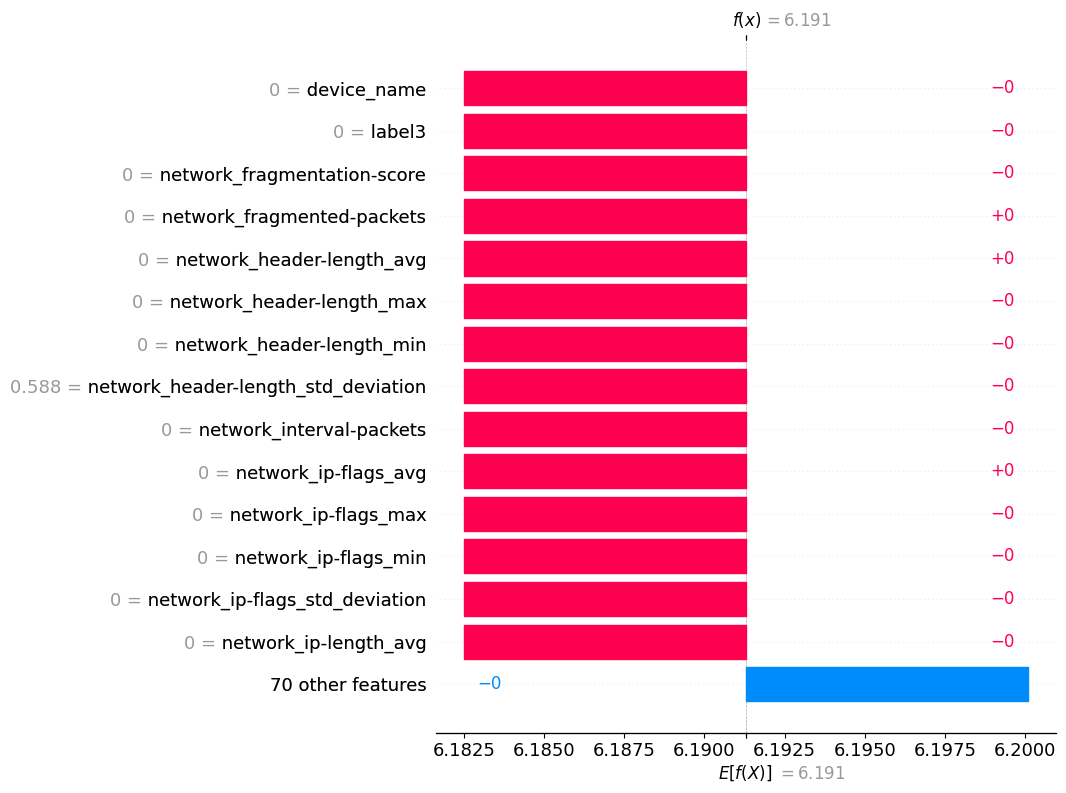



MODEL: decision_tree
Raw SHAP shape: (1, 107, 84)


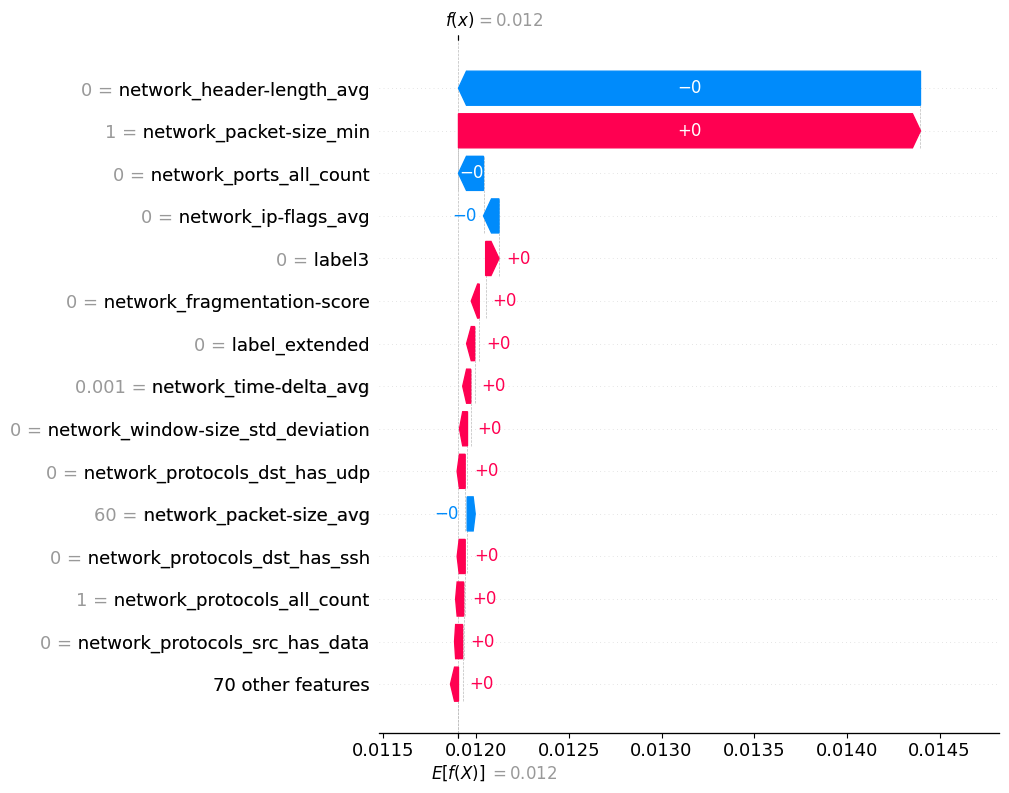



MODEL: random_forest
Raw SHAP shape: (1, 107, 84)


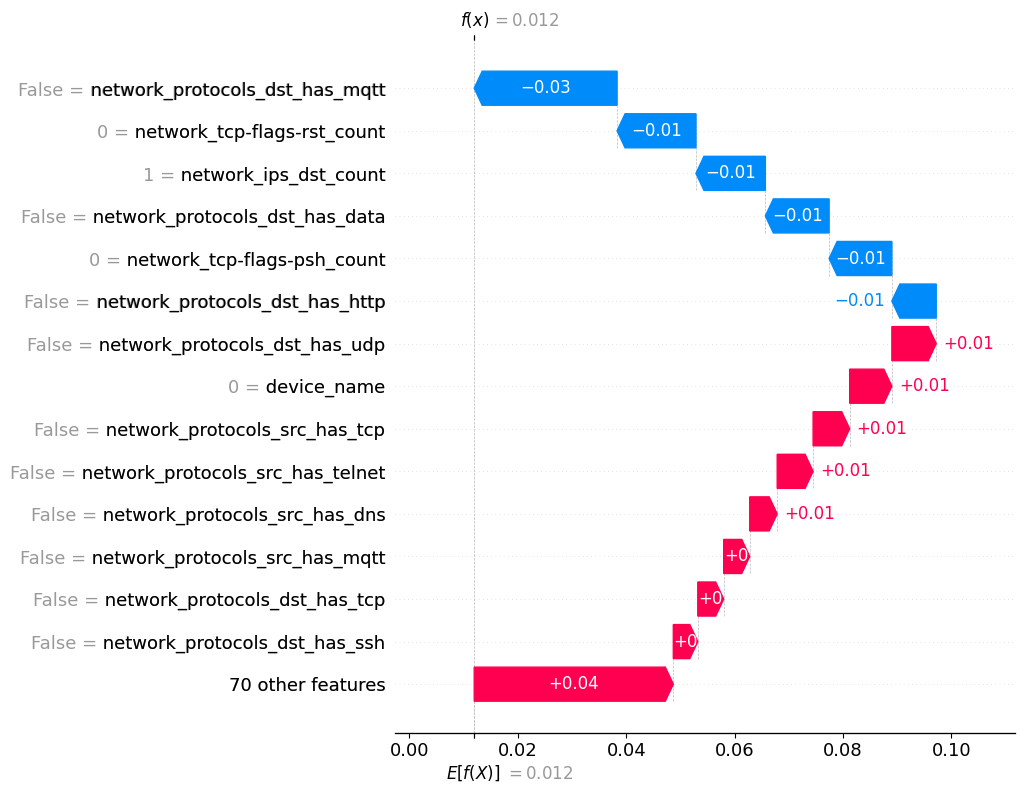

In [26]:
sample = X_test.sample(
    n=1,
    random_state=42
)

for name, model in MODELS.items():

    print("\n")
    print("="*60)
    print("MODEL:", name)
    print("="*60)

    pre, final_model = split_pipeline(model)

    
    # RESPEITA SCHEMA DO PIPELINE
    

    if pre is not None:

        cols = pre.feature_names_in_

        X_fixed = sample.reindex(
            columns=cols,
            fill_value=0
        )

        X_trans = pre.transform(
            X_fixed
        )

    else:

        X_trans = sample


    
    # CALCULA SHAP
    

    if "tree" in name or "forest" in name:

        explainer = shap.TreeExplainer(
            final_model
        )

        values = explainer.shap_values(
            X_trans
        )

        base = explainer.expected_value


    elif "logistic" in name:

        explainer = shap.LinearExplainer(
            final_model,
            X_trans
        )

        values = explainer.shap_values(
            X_trans
        )

        base = explainer.expected_value


    else:

        explainer = shap.Explainer(
            final_model,
            X_trans
        )

        exp = explainer(
            X_trans
        )

        values = exp.values
        base = exp.base_values


    
    # NORMALIZA DIMENSÕES
    

    values = np.array(values)

    print("Raw SHAP shape:", values.shape)

    # Caso: lista multiclass
    if isinstance(values, list):

        values = values[1]

    values = np.array(values)


    # (classes, amostras, features)
    if values.ndim == 3:

        values = values[0,0,:]

        if isinstance(base, (list,np.ndarray)):
            base = base[0]

    # (amostras,features)
    elif values.ndim == 2:

        values = values[0]

        if isinstance(base,(list,np.ndarray)):
            base = base[0]


    explanation = shap.Explanation(
        values=values,
        base_values=base,
        data=X_trans[0],
        feature_names=sample.columns
    )


    
    # WATERFALL
    

    plt.figure(figsize=(12,7))

    shap.plots.waterfall(
        explanation,
        max_display=15,
        show=False
    )

    plt.show()

# 8. ANÁLISE CIENTÍFICA AUTOMÁTICA FP vs FN

In [27]:

# Objetivo:
# Interpretar automaticamente as causas dos erros
# usando SHAP
#
# Gera:
# - Top drivers de FP
# - Top drivers de FN
# - Diagnóstico automático


TOP_K = 5

for name, model in MODELS.items():

    print("\n")
    print("="*70)
    print("MODELO:", name.upper())
    print("="*70)

    pred = model.predict(X_test)

    errors = pd.DataFrame({
        "real": y_test.values,
        "pred": pred
    })

    FP_idx = errors[
        (errors.real=="benign") &
        (errors.pred!="benign")
    ].index

    FN_idx = errors[
        (errors.real!="benign") &
        (errors.pred=="benign")
    ].index

    TP_idx = errors[
        (errors.real!="benign") &
        (errors.pred!="benign")
    ].index

    print(f"\nFP: {len(FP_idx)}")
    print(f"FN: {len(FN_idx)}")
    print(f"TP: {len(TP_idx)}")


    
    # amostragem
    

    X_tp = X_test.loc[TP_idx].sample(
        min(500,len(TP_idx)),
        random_state=42
    )

    X_fp = X_test.loc[FP_idx].sample(
        min(500,len(FP_idx)),
        random_state=42
    )

    X_fn = X_test.loc[FN_idx].sample(
        min(500,len(FN_idx)),
        random_state=42
    )


    
    # SHAP
    

    tp_s,_ = get_shap(
        model,
        X_tp,
        name
    )

    fp_s,_ = get_shap(
        model,
        X_fp,
        name
    )

    fn_s,_ = get_shap(
        model,
        X_fn,
        name
    )


    tp = reduce_shap(tp_s)
    fp = reduce_shap(fp_s)
    fn = reduce_shap(fn_s)


    features = X_test.columns[:len(tp)]

    df = pd.DataFrame({

        "feature":features,
        "TP":tp,
        "FP":fp,
        "FN":fn

    })


    df["FP_minus_TP"] = (
        df["FP"] - df["TP"]
    )

    df["FN_minus_TP"] = (
        df["FN"] - df["TP"]
    )


    top_fp = (
        df
        .sort_values(
            "FP_minus_TP",
            ascending=False
        )
        .head(TOP_K)
    )


    top_fn = (
        df
        .sort_values(
            "FN_minus_TP",
            ascending=False
        )
        .head(TOP_K)
    )


    print("\n")
    print("-"*50)
    print("TOP FEATURES ASSOCIADAS A FP")
    print("-"*50)

    display(
        top_fp[
            ["feature","FP_minus_TP"]
        ]
    )


    print("\n")
    print("-"*50)
    print("TOP FEATURES ASSOCIADAS A FN")
    print("-"*50)

    display(
        top_fn[
            ["feature","FN_minus_TP"]
        ]
    )





MODELO: LOGISTIC_REGRESSION

FP: 17888
FN: 2051
TP: 20547


--------------------------------------------------
TOP FEATURES ASSOCIADAS A FP
--------------------------------------------------


,feature,FP_minus_TP
4,network_header-length_avg,0.367879
23,network_mss_avg,0.358420
2,network_fragmentation-score,0.211154
7,network_header-length_std_deviation,0.208708
16,network_ip-length_std_deviation,0.193059




--------------------------------------------------
TOP FEATURES ASSOCIADAS A FN
--------------------------------------------------


,feature,FN_minus_TP
7,network_header-length_std_deviation,0.012071
15,network_ip-length_min,0.012036
1,label3,0.000000
21,network_macs_dst_count,0.000000
20,network_macs_all_count,0.000000




MODELO: DECISION_TREE

FP: 4305
FN: 2414
TP: 20184


--------------------------------------------------
TOP FEATURES ASSOCIADAS A FP
--------------------------------------------------


...

,feature,FN_minus_TP
51,network_tcp-flags_max,0.001587
26,network_mss_std_deviation,0.001582
23,network_mss_avg,0.001103
54,network_time-delta_avg,0.000683
86,network_protocols_dst_has_icmp,0.000387




MODELO: RANDOM_FOREST

FP: 7183
FN: 2071
TP: 20527


--------------------------------------------------
TOP FEATURES ASSOCIADAS A FP
--------------------------------------------------


,feature,FP_minus_TP
0,device_name,0.001351
2,network_fragmentation-score,0.000838
28,network_packet-size_max,0.000830
1,label3,0.000641
57,network_time-delta_std_deviation,0.000493




--------------------------------------------------
TOP FEATURES ASSOCIADAS A FN
--------------------------------------------------


,feature,FN_minus_TP
28,network_packet-size_max,0.000571
0,device_name,0.000555
54,network_time-delta_avg,0.000433
29,network_packet-size_min,0.000293
26,network_mss_std_deviation,0.000265


# 9. SHAP MULTICLASSE

In [28]:

# SHAP MULTICLASSE


def split_pipeline(model):

    if hasattr(
        model,
        "named_steps"
    ):

        return (

            model[:-1],
            model[-1]

        )

    return None,model



def get_shap_multi(

    model,
    X_sample,
    name

):

    pre,final_model=split_pipeline(
        model
    )

    if pre is not None:

        X_trans=pre.transform(
            X_sample
        )

    else:

        X_trans=X_sample


    if (

        "tree" in name or
        "forest" in name

    ):

        explainer=shap.TreeExplainer(
            final_model
        )

        values=explainer.shap_values(
            X_trans
        )


    elif "logistic" in name:

        explainer=shap.LinearExplainer(

            final_model,
            X_trans

        )

        values=explainer.shap_values(
            X_trans
        )

    else:

        explainer=shap.Explainer(
            final_model
        )

        values=explainer(
            X_trans
        ).values


    return np.array(
        values
    ),X_trans

In [29]:

# SHAP GLOBAL MULTICLASSE
# REMOVE FEATURES "device"


sample=X_test.sample(
    300,
    random_state=42
)

for name,model in MODELS_MULTI.items():

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    values,X_trans=get_shap_multi(
        model,
        sample,
        name
    )

    values=np.array(values)

    pre,final_model=split_pipeline(
        model
    )


    # ========================================================
    # CLASSES
    # ========================================================

    classes=final_model.classes_

    print(
        "Classes modelo:"
    )

    print(
        classes
    )


    # ========================================================
    # FEATURES
    # ========================================================

    try:

        feature_names=(
            pre.get_feature_names_out()
        )

    except:

        feature_names=np.array(
            X_test.columns
        )


    n_features=len(
        feature_names
    )

    n_classes=len(
        classes
    )


    print(
        "Shape original:",
        values.shape
    )


    # ========================================================
    # AJUSTA DIMENSÕES
    # ========================================================

    if values.ndim==3:

        # (samples,features,classes)

        if values.shape[1]==n_features:

            values=np.transpose(
                values,
                (0,2,1)
            )

        # (classes,samples,features)

        elif values.shape[0]==n_classes:

            values=np.transpose(
                values,
                (1,0,2)
            )


    print(
        "Shape ajustado:",
        values.shape
    )


    # ========================================================
    # REMOVE FEATURES DEVICE
    # ========================================================

    keep_idx=[

        i

        for i,f in enumerate(
            feature_names
        )

        if "device" not in f.lower()

    ]


    filtered_features=feature_names[
        keep_idx
    ]


    print(
        "\nFeatures removidas:"
    )

    removed=[

        f

        for f in feature_names

        if "device" in f.lower()

    ]

    print(
        removed
    )


    # ========================================================
    # LOOP CLASSES
    # ========================================================

    max_classes=min(

        n_classes,
        values.shape[1]

    )


    for i in range(
        max_classes
    ):

        cls=classes[i]

        print(
            "\nClasse:",
            cls
        )

        class_values=values[
            :,
            i,
            keep_idx
        ]


        importance=np.mean(

            np.abs(
                class_values
            ),

            axis=0

        )


        df=pd.DataFrame({

            "feature":
            filtered_features,

            "importance":
            importance

        })


        display(

            df
            .sort_values(
                "importance",
                ascending=False
            )
            .head(10)

        )



logistic_regression_multi
Classes modelo:
['benign' 'bruteforce' 'ddos' 'dos' 'malware' 'mitm' 'recon' 'web']
Shape original: (300, 49, 8)
Shape ajustado: (300, 8, 49)

Features removidas:
['device_type_infra', 'device_type_iot']

Classe: benign


,feature,importance
10,network_ports_src_count,1.730003
17,network_window-size_min,0.576726
9,network_payload-length_min,0.446383
5,network_mss_min,0.399922
12,network_tcp-flags-psh_count,0.387768
0,network_fragmented-packets,0.355104
43,network_ports_dst_has_80,0.344436
44,network_ports_dst_has_23,0.342145
30,network_protocols_dst_has_mqtt,0.314425
11,network_tcp-flags-fin_count,0.230601



Classe: bruteforce


,feature,importance
43,network_ports_dst_has_80,1.193467
10,network_ports_src_count,1.047427
12,network_tcp-flags-psh_count,0.970817
37,network_ports_src_has_80,0.806133
30,network_protocols_dst_has_mqtt,0.782694
44,network_ports_dst_has_23,0.775566
23,network_protocols_src_has_telnet,0.533620
29,network_protocols_dst_has_data,0.463485
41,network_ports_dst_has_443,0.461375
4,network_ip-flags_std_deviation,0.438611



Classe: ddos


...

,feature,importance
27,network_packet-size_min,0.031532
30,network_packets_dst_count,0.017924
29,network_packets_all_count,0.014146
62,network_window-size_min,0.012800
13,network_ip-length_min,0.011425
36,network_ports_all_count,0.010569
11,network_ip-length_avg,0.010224
63,network_window-size_std_deviation,0.008397
61,network_window-size_max,0.007660
60,network_window-size_avg,0.006258



Classe: recon


,feature,importance
58,network_ttl_min,0.022106
30,network_packets_dst_count,0.021028
45,network_tcp-flags-rst_count,0.018602
51,network_tcp-flags_std_deviation,0.017959
29,network_packets_all_count,0.016628
62,network_window-size_min,0.014651
60,network_window-size_avg,0.012196
27,network_packet-size_min,0.012062
46,network_tcp-flags-syn_count,0.010987
22,network_mss_max,0.010097



Classe: web


,feature,importance
13,network_ip-length_min,0.015860
58,network_ttl_min,0.012326
18,network_macs_all_count,0.009997
30,network_packets_dst_count,0.007953
48,network_tcp-flags_avg,0.006182
29,network_packets_all_count,0.005682
59,network_ttl_std_deviation,0.004571
15,network_ips_all_count,0.004448
25,network_packet-size_avg,0.004398
27,network_packet-size_min,0.004106


# 10. FP/FN SHAP MULTICLASSE

In [30]:

# FP/FN SHAP MULTICLASSE
# CORRIGIDO


TOP_K=5

for name,model in MODELS_MULTI.items():

    print("\n")
    print("="*80)
    print(name.upper())
    print("="*80)

    pre,final_model=split_pipeline(
        model
    )

    classes=final_model.classes_

    pred=model.predict(
        X_test
    )

    errors=pd.DataFrame({

        "real":
        y_test_multi.values,

        "pred":
        pred

    })

    # ========================================================
    # FEATURES CORRETAS
    # ========================================================

    try:

        feature_names=(
            pre.get_feature_names_out()
        )

    except:

        feature_names=X_test.columns


    n_features=len(
        feature_names
    )


    for idx,cls in enumerate(
        classes
    ):

        print("\n")
        print(
            f"Classe: {cls}"
        )

        TP_idx=errors[

            (errors.real==cls)&
            (errors.pred==cls)

        ].index


        FP_idx=errors[

            (errors.real!=cls)&
            (errors.pred==cls)

        ].index


        FN_idx=errors[

            (errors.real==cls)&
            (errors.pred!=cls)

        ].index


        print(

            f"TP={len(TP_idx)} "
            f"FP={len(FP_idx)} "
            f"FN={len(FN_idx)}"

        )


        if (

            len(TP_idx)<5 or
            len(FP_idx)<5 or
            len(FN_idx)<5

        ):

            continue


        X_tp=X_test.loc[
            TP_idx
        ].sample(
            min(
                300,
                len(TP_idx)
            ),
            random_state=42
        )


        X_fp=X_test.loc[
            FP_idx
        ].sample(
            min(
                300,
                len(FP_idx)
            ),
            random_state=42
        )


        X_fn=X_test.loc[
            FN_idx
        ].sample(
            min(
                300,
                len(FN_idx)
            ),
            random_state=42
        )


        tp_s,_=get_shap_multi(
            model,
            X_tp,
            name
        )

        fp_s,_=get_shap_multi(
            model,
            X_fp,
            name
        )

        fn_s,_=get_shap_multi(
            model,
            X_fn,
            name
        )


        tp_s=np.array(tp_s)
        fp_s=np.array(fp_s)
        fn_s=np.array(fn_s)


        # ====================================================
        # AJUSTA DIMENSÃO
        # objetivo:
        # (samples,classes,features)
        # ====================================================

        def normalize(x):

            if x.ndim==3:

                # (samples,features,classes)

                if x.shape[1]==n_features:

                    x=np.transpose(
                        x,
                        (0,2,1)
                    )

                # (classes,samples,features)

                elif x.shape[0]==len(classes):

                    x=np.transpose(
                        x,
                        (1,0,2)
                    )

            return x


        tp_s=normalize(tp_s)
        fp_s=normalize(fp_s)
        fn_s=normalize(fn_s)


        tp=np.mean(
            np.abs(
                tp_s[:,idx,:]
            ),
            axis=0
        )

        fp=np.mean(
            np.abs(
                fp_s[:,idx,:]
            ),
            axis=0
        )

        fn=np.mean(
            np.abs(
                fn_s[:,idx,:]
            ),
            axis=0
        )


        print(
            "Features:",
            len(feature_names)
        )

        print(
            "TP:",
            len(tp)
        )


        df=pd.DataFrame({

            "feature":
            feature_names,

            "TP":
            tp,

            "FP":
            fp,

            "FN":
            fn

        })


        df[
            "FP_minus_TP"
        ]=(

            df["FP"]
            -
            df["TP"]

        )

        df[
            "FN_minus_TP"
        ]=(

            df["FN"]
            -
            df["TP"]

        )


        print("\nTOP FP")

        display(

            df
            .sort_values(
                "FP_minus_TP",
                ascending=False
            )
            .head(TOP_K)

        )


        print("\nTOP FN")

        display(

            df
            .sort_values(
                "FN_minus_TP",
                ascending=False
            )
            .head(TOP_K)

        )



LOGISTIC_REGRESSION_MULTI


Classe: benign
TP=27309 FP=3469 FN=6891
Features: 49
TP: 49

TOP FP


,feature,TP,FP,FN,FP_minus_TP,FN_minus_TP
17,network_window-size_min,0.568078,0.599142,0.557895,0.031064,-0.010183
10,network_ports_src_count,0.436191,0.453648,0.684648,0.017456,0.248457
12,network_tcp-flags-psh_count,0.196078,0.205429,0.422237,0.009351,0.226160
43,network_ports_dst_has_443,0.000000,0.007524,0.030095,0.007524,0.030095
23,network_protocols_src_has_mqtt,0.052121,0.055321,0.043978,0.003200,-0.008142



TOP FN


,feature,TP,FP,FN,FP_minus_TP,FN_minus_TP
19,device_type_iot,0.133938,0.080363,3.849389,-0.053575,3.715451
18,device_type_infra,0.076565,0.045939,2.093892,-0.030626,2.017328
32,network_protocols_dst_has_mqtt,0.008037,0.000000,0.642675,-0.008037,0.634637
3,network_ip-flags_min,0.045558,0.020522,0.348459,-0.025037,0.302901
10,network_ports_src_count,0.436191,0.453648,0.684648,0.017456,0.248457




Classe: bruteforce
TP=0 FP=2970 FN=0


Classe: ddos
TP=0 FP=3471 FN=0


Classe: dos
TP=0 FP=4364 FN=0


Classe: malware
TP=0 FP=1947 FN=0


Classe: mitm
TP=0 FP=4512 FN=0


Classe: recon
TP=0 FP=6994 FN=0


Classe: web
TP=0 FP=1762 FN=0


DECISION_TREE_MULTI


Classe: benign
TP=30717 FP=2420 FN=3483
Features: 107
TP: 107

TOP FP


...



Classe: bruteforce
TP=0 FP=2253 FN=0


Classe: ddos
TP=0 FP=4116 FN=0


Classe: dos
TP=0 FP=4365 FN=0


Classe: malware
TP=0 FP=2143 FN=0


Classe: mitm
TP=0 FP=2093 FN=0


Classe: recon
TP=0 FP=6964 FN=0


Classe: web
TP=0 FP=1727 FN=0


RANDOM_FOREST_MULTI


Classe: benign
TP=30702 FP=2464 FN=3498
Features: 107
TP: 107

TOP FP


,feature,TP,FP,FN,FP_minus_TP,FN_minus_TP
56,network_time-delta_max,0.005587,0.007238,0.004547,0.001651,-0.001040
57,network_time-delta_min,0.005803,0.007115,0.004317,0.001312,-0.001486
55,network_time-delta_avg,0.008609,0.009543,0.006383,0.000934,-0.002226
62,network_ttl_std_deviation,0.005185,0.005713,0.002625,0.000528,-0.002561
1,device_type_infra,0.003314,0.003782,0.007495,0.000468,0.004181



TOP FN


,feature,TP,FP,FN,FP_minus_TP,FN_minus_TP
1,device_type_infra,0.003314,0.003782,0.007495,0.000468,0.004181
45,network_tcp-flags-ack_count,0.000309,0.000233,0.000646,-0.000076,0.000338
90,network_ports_src_has_22,0.000320,0.000341,0.000628,0.000022,0.000309
29,network_packet-size_max,0.001733,0.001683,0.002036,-0.000051,0.000303
52,network_tcp-flags_max,0.000370,0.000311,0.000576,-0.000059,0.000205




Classe: bruteforce
TP=0 FP=2401 FN=0


Classe: ddos
TP=0 FP=3882 FN=0


Classe: dos
TP=0 FP=4366 FN=0


Classe: malware
TP=0 FP=2059 FN=0


Classe: mitm
TP=0 FP=2262 FN=0


Classe: recon
TP=0 FP=6900 FN=0


Classe: web
TP=0 FP=1762 FN=0


# 11. GRÁFICOS SHAP


Gerando gráficos binários...


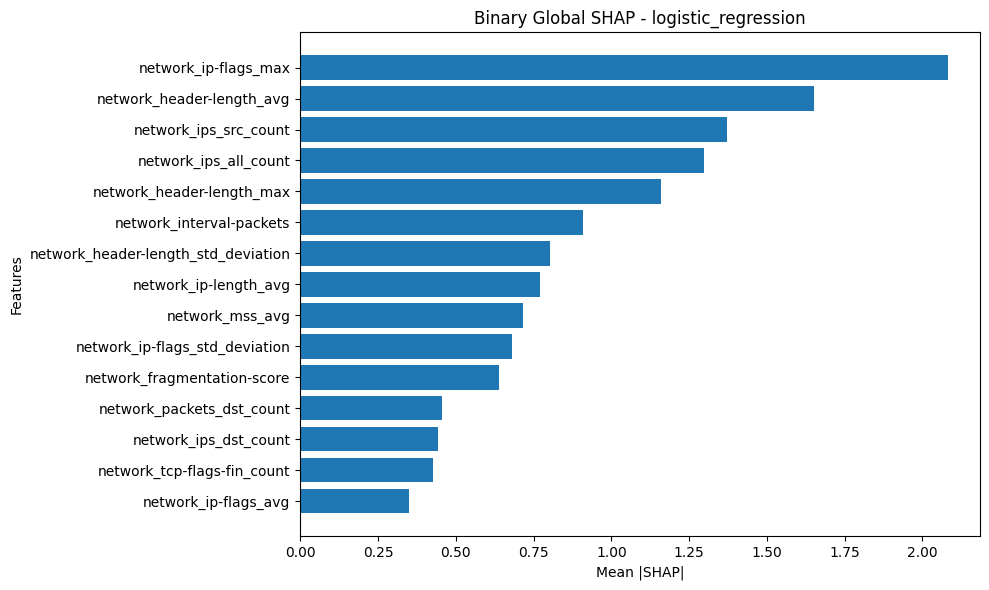

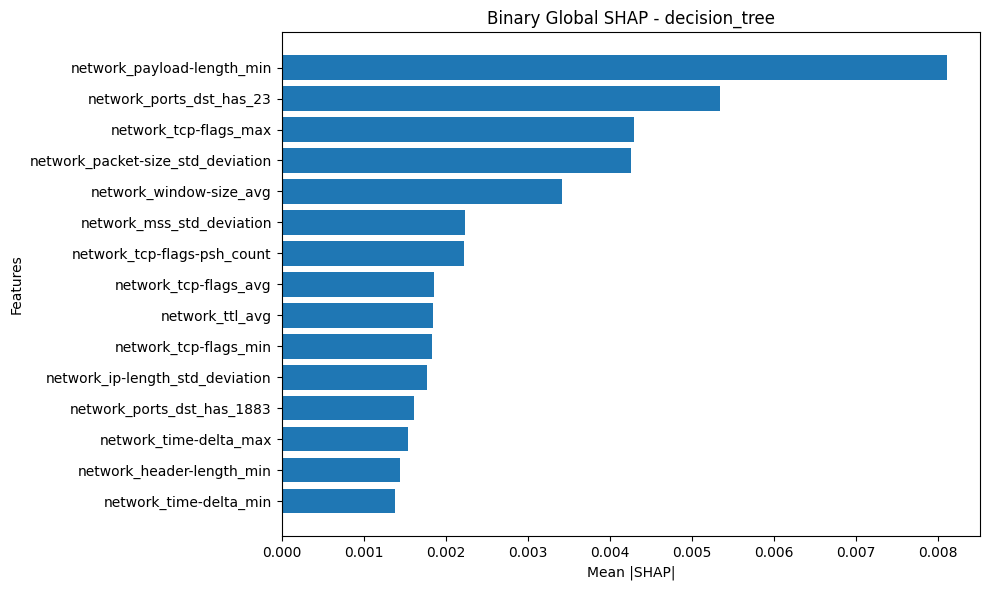

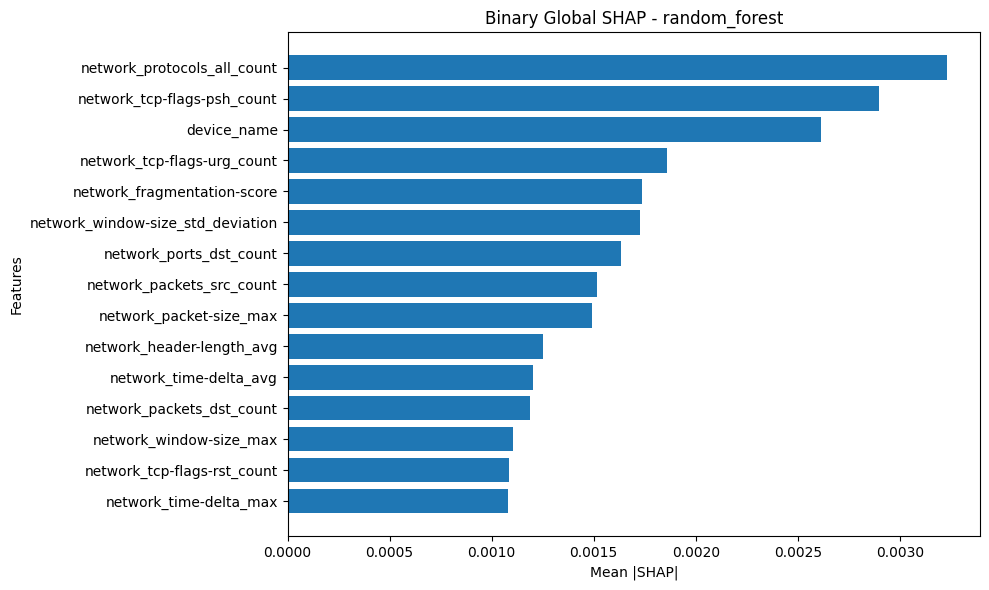


Gerando multiclass macro...


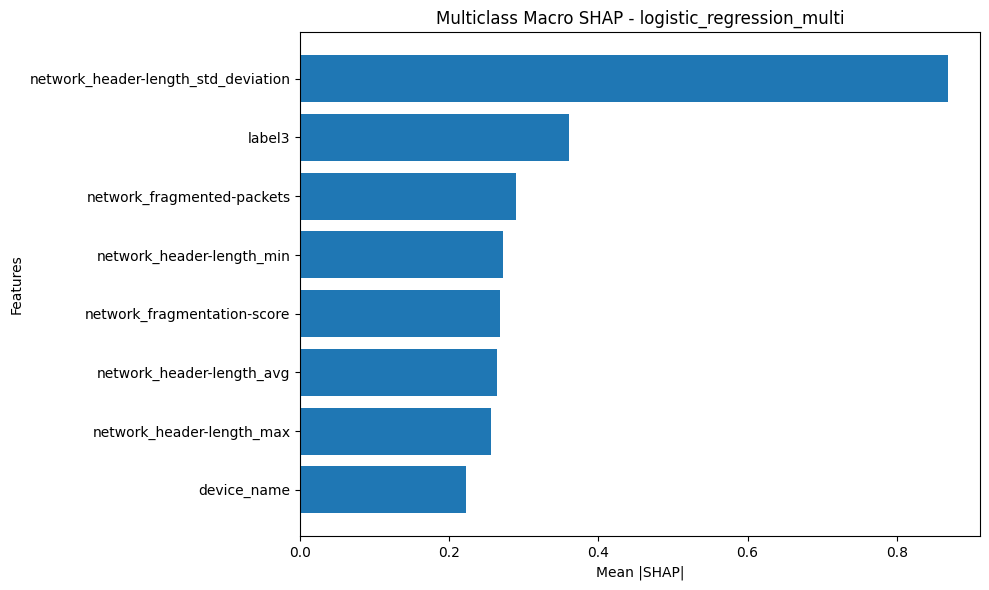

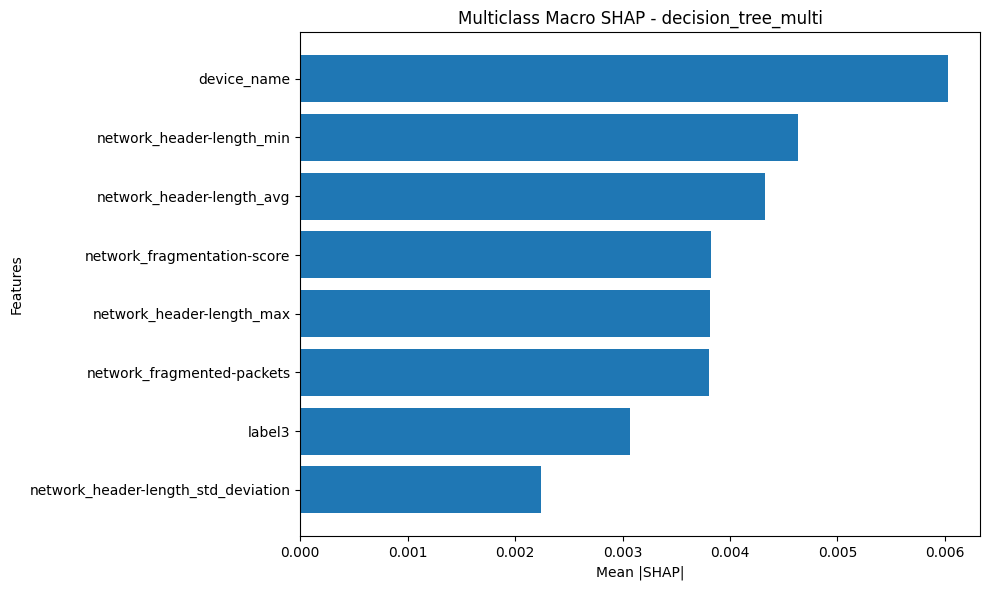

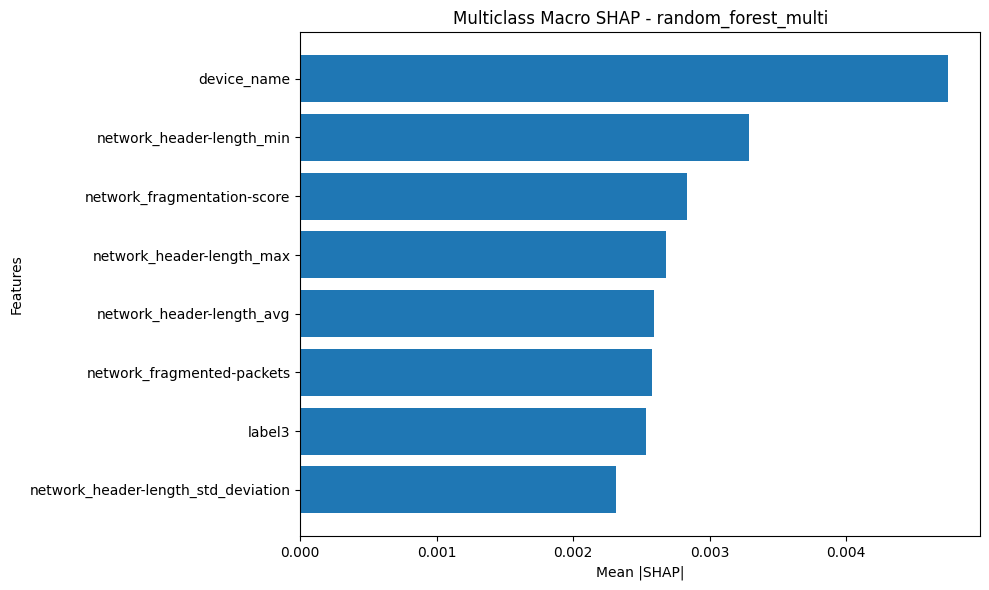


Gerando SHAP por classe...


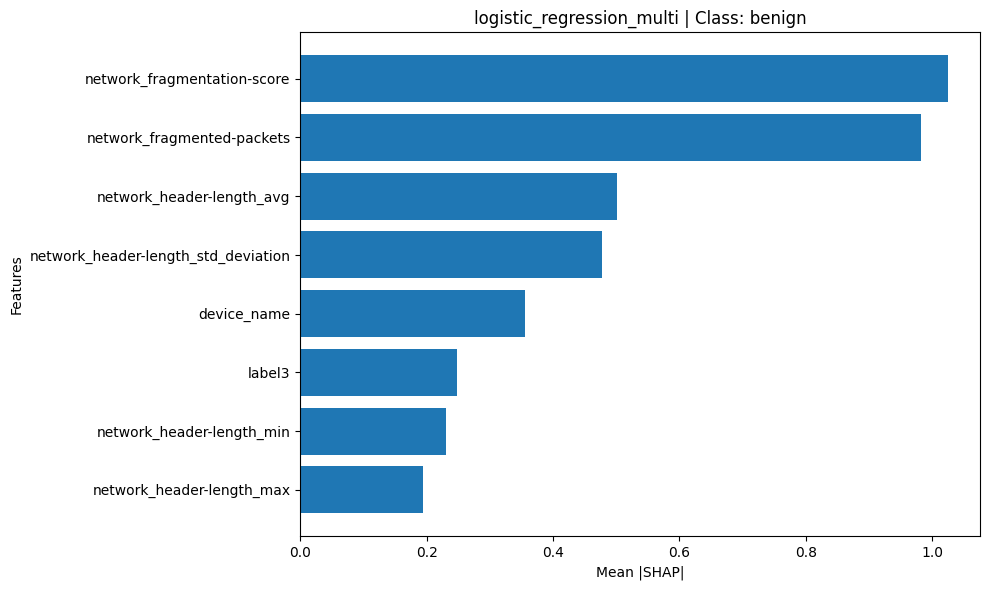

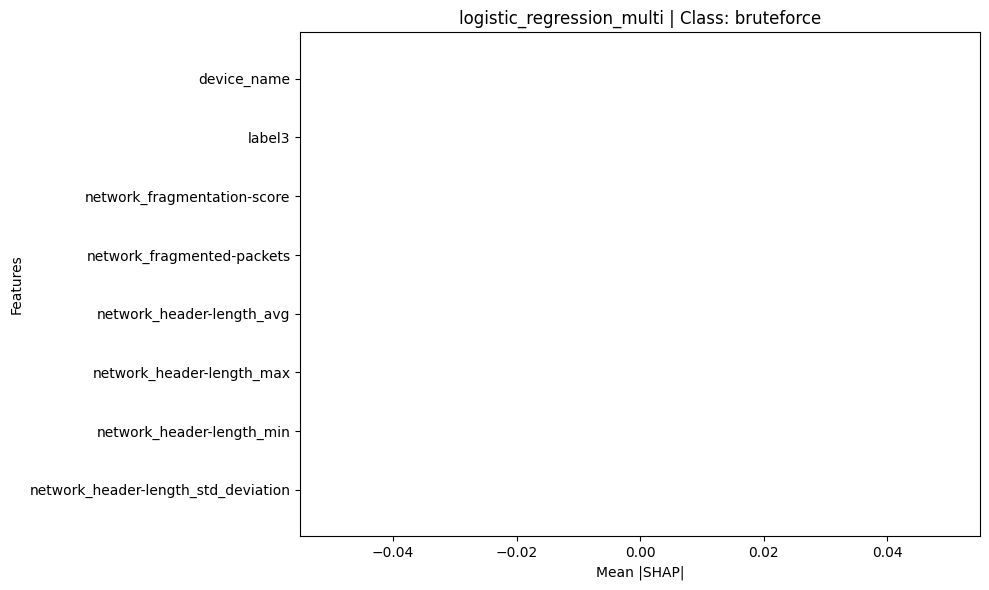

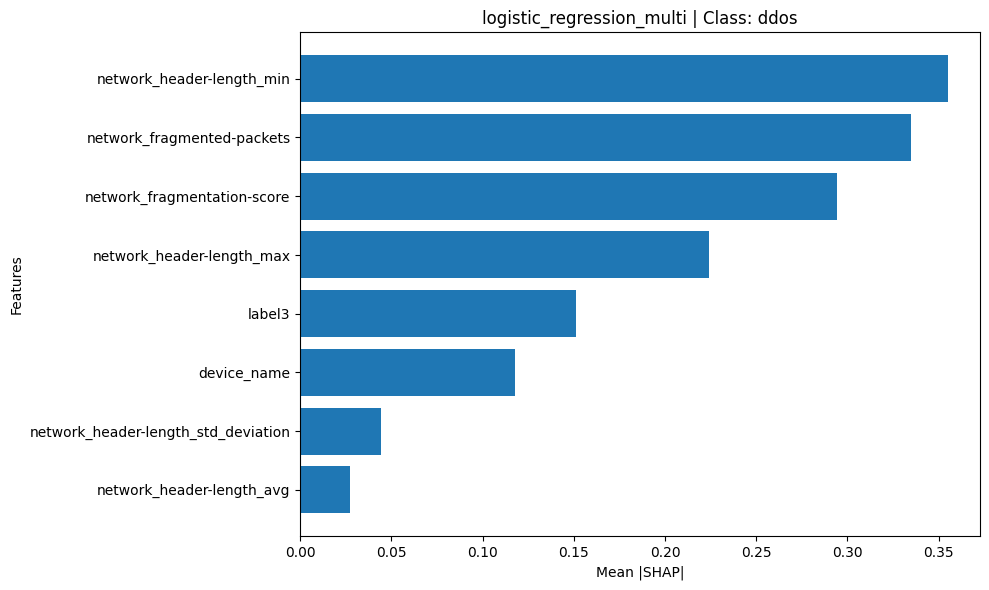

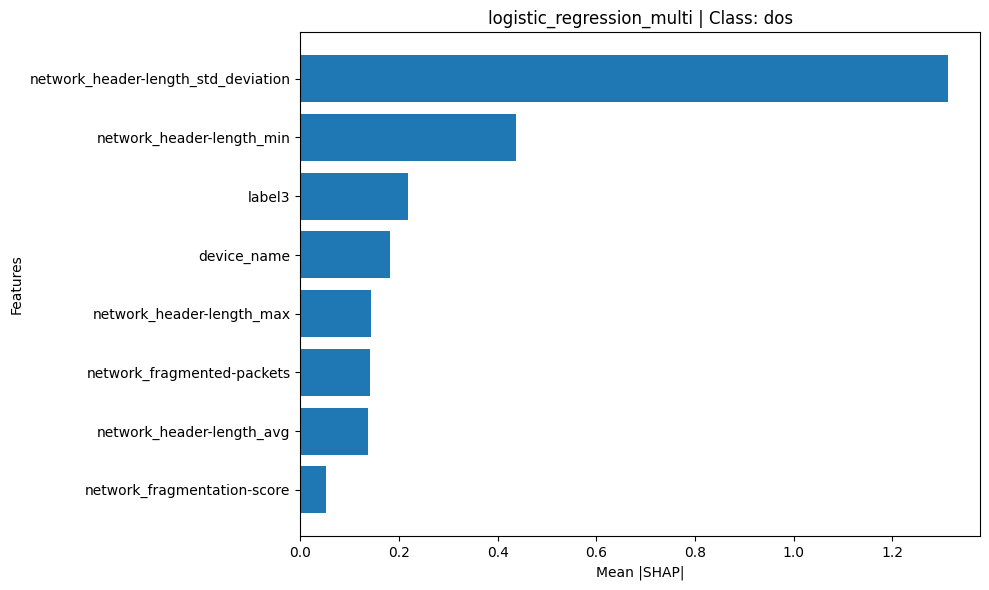

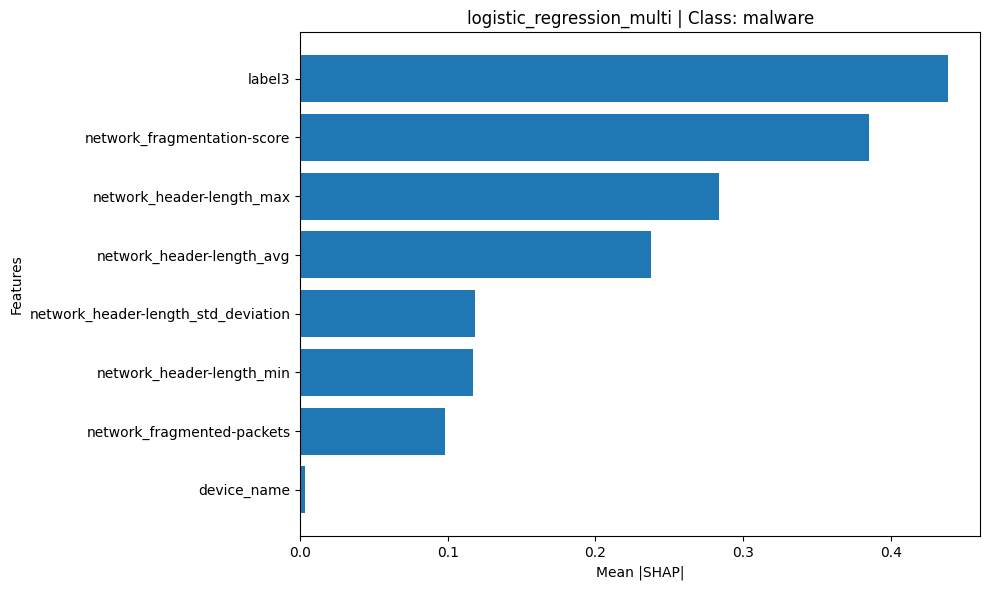

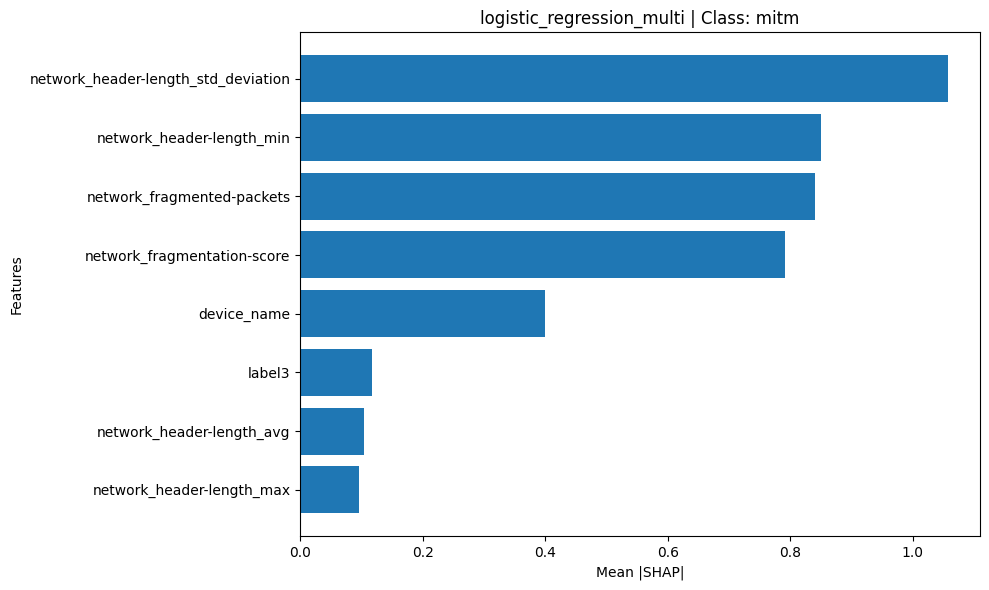

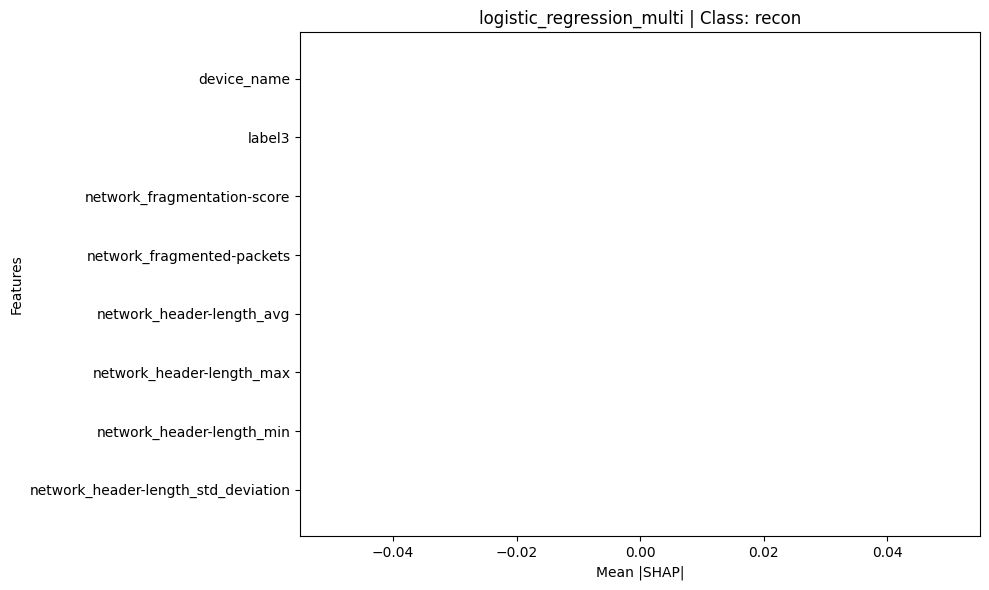

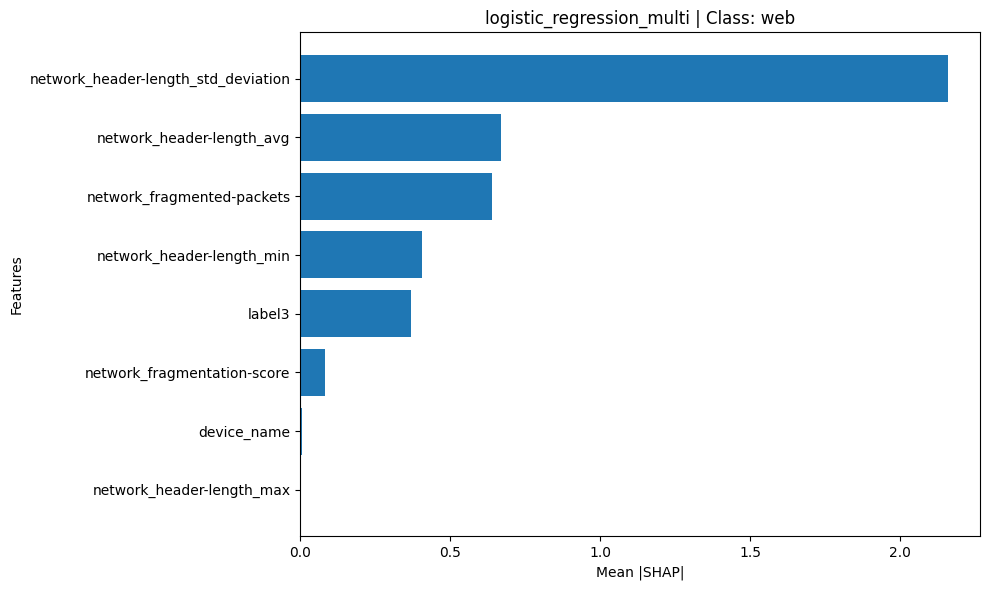

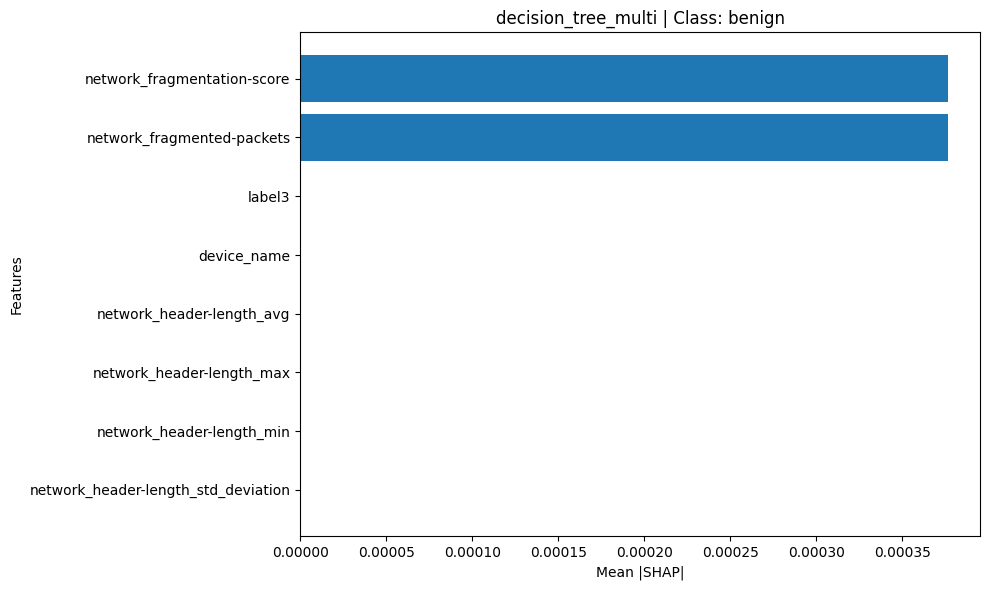

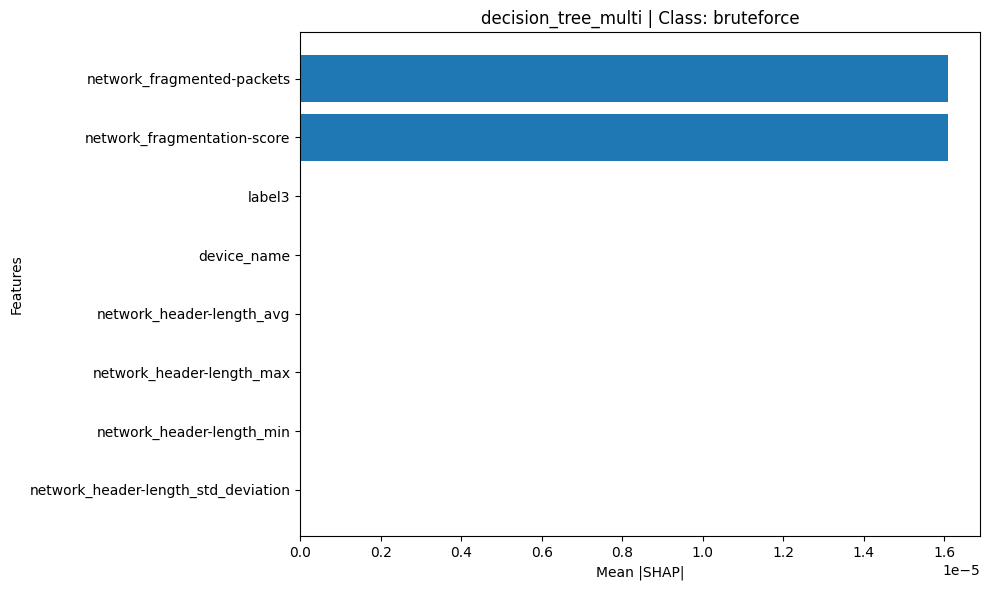

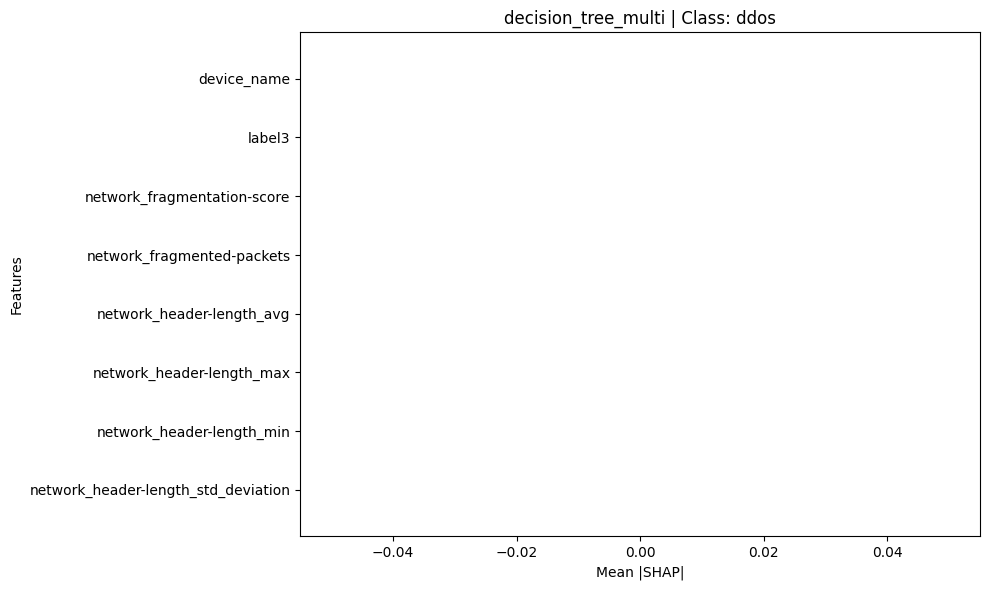

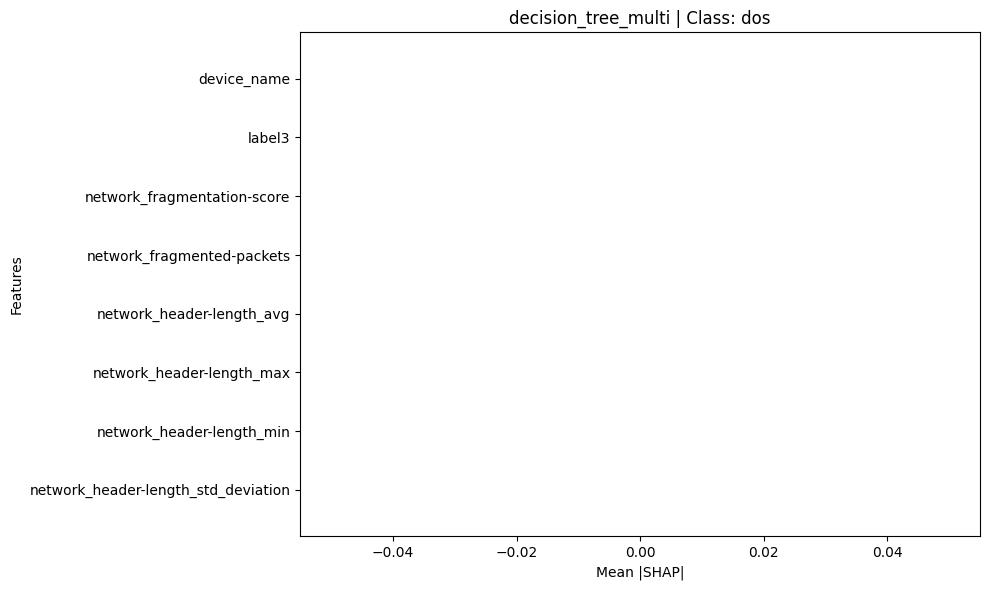

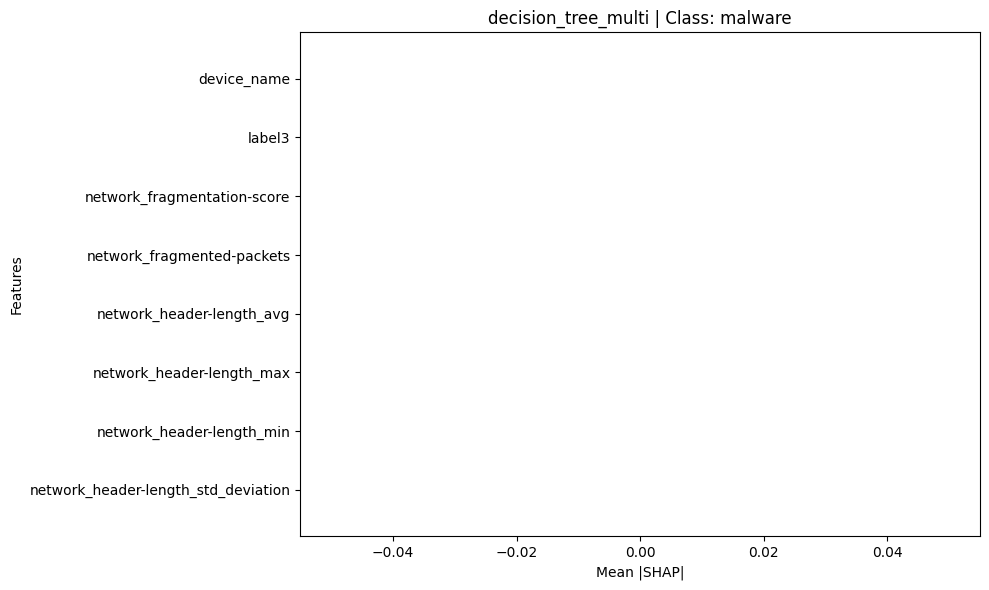

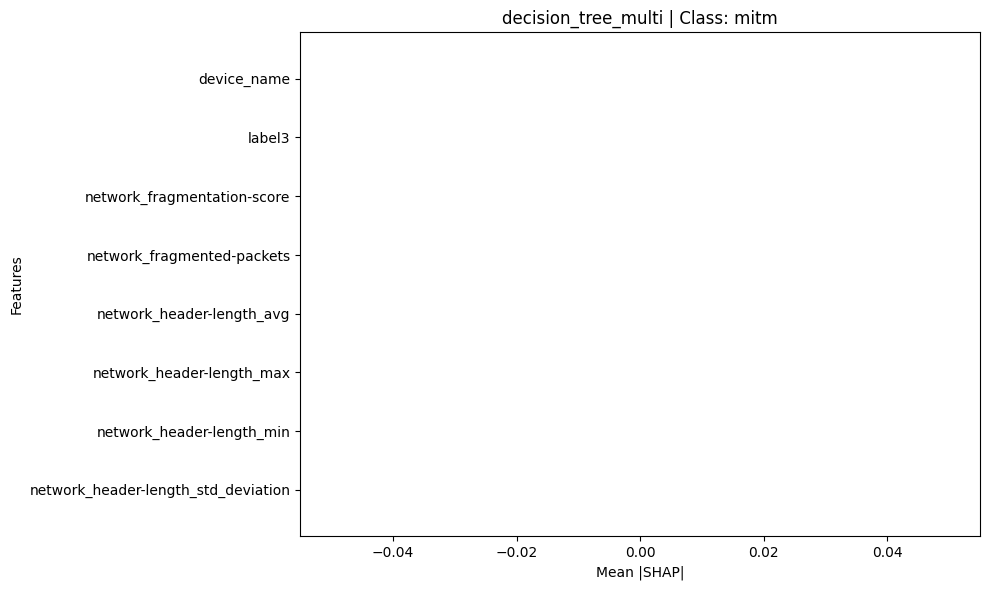

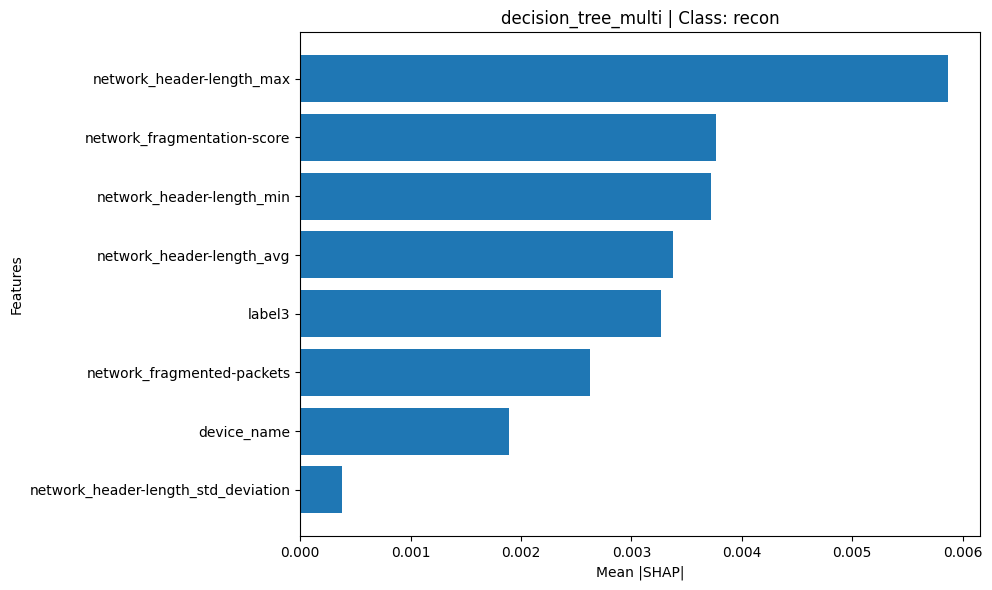

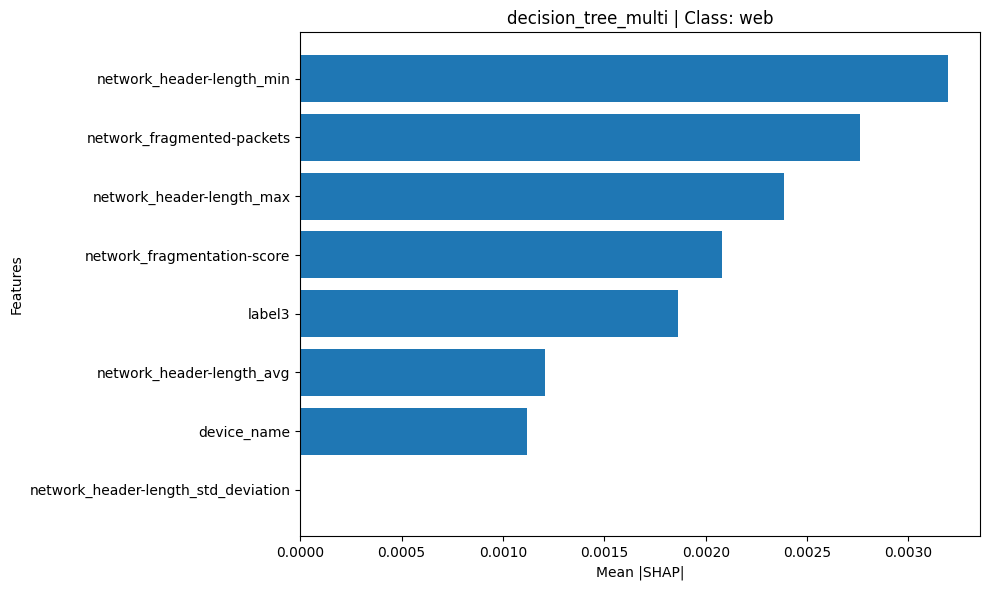

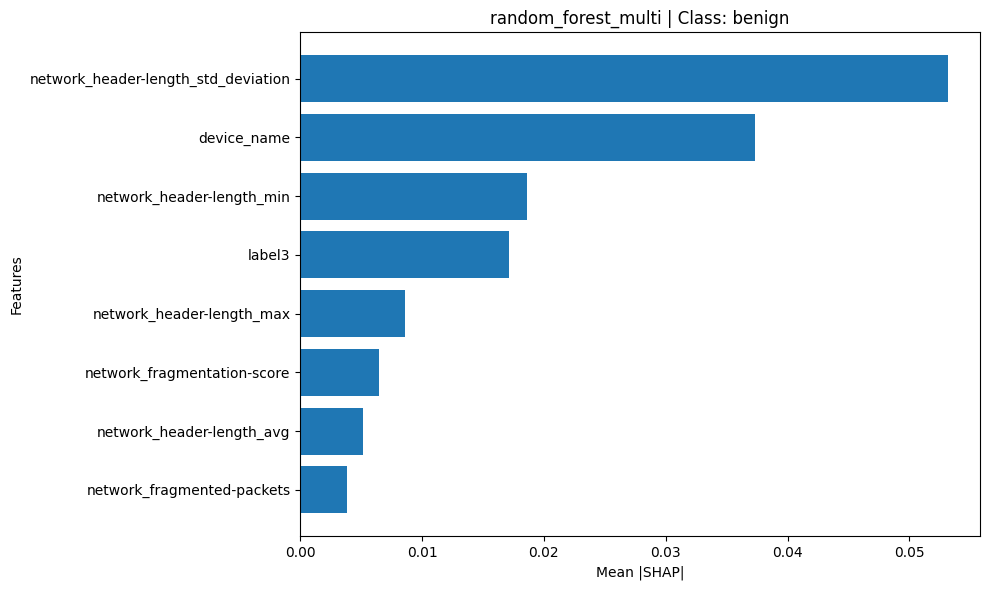

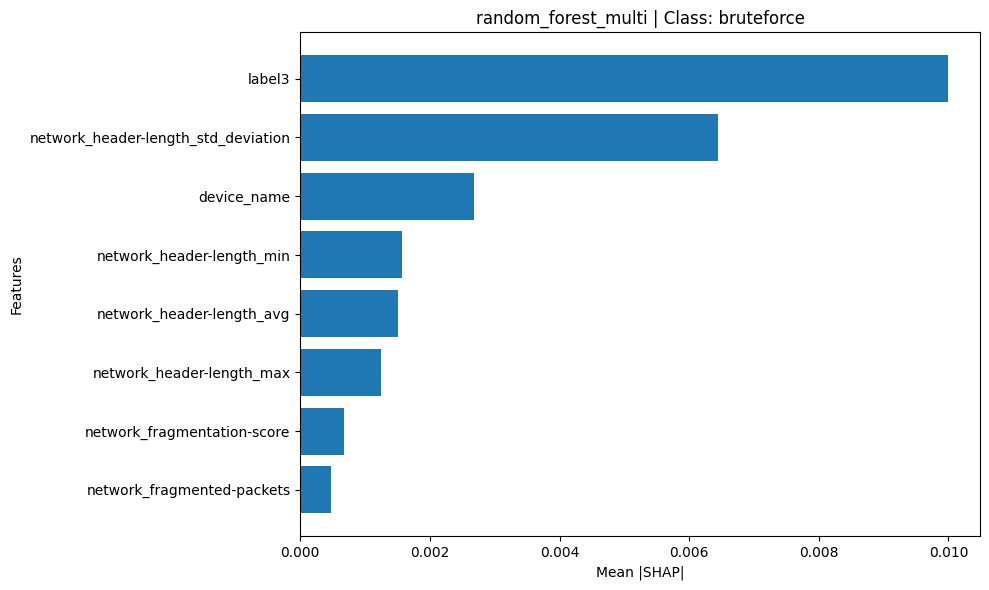

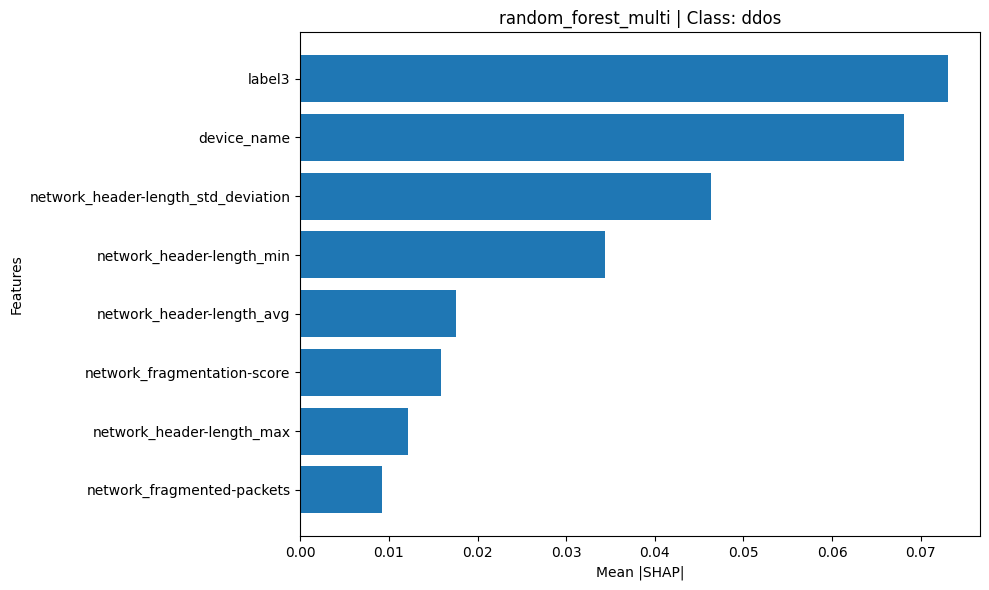

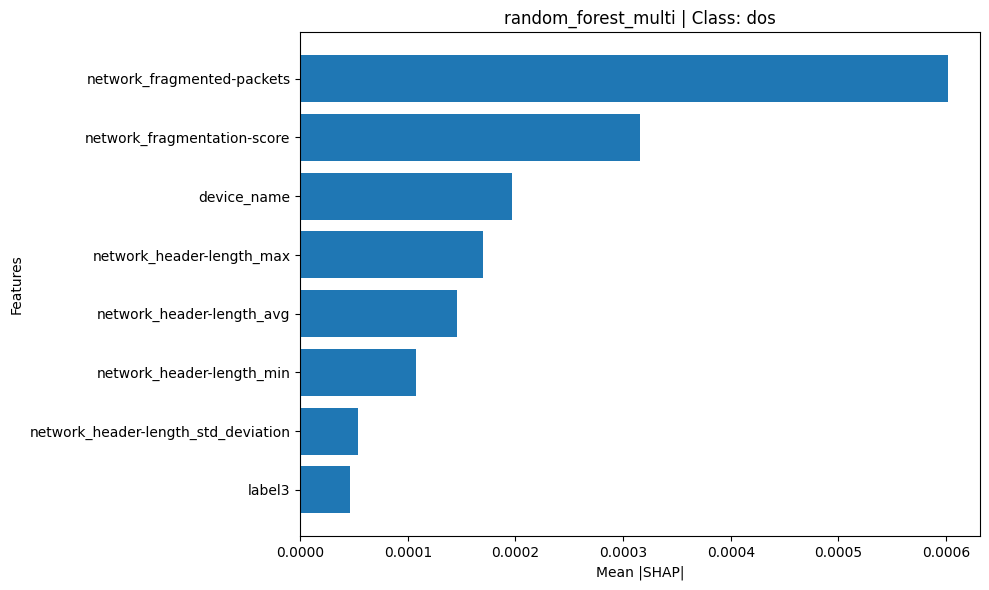

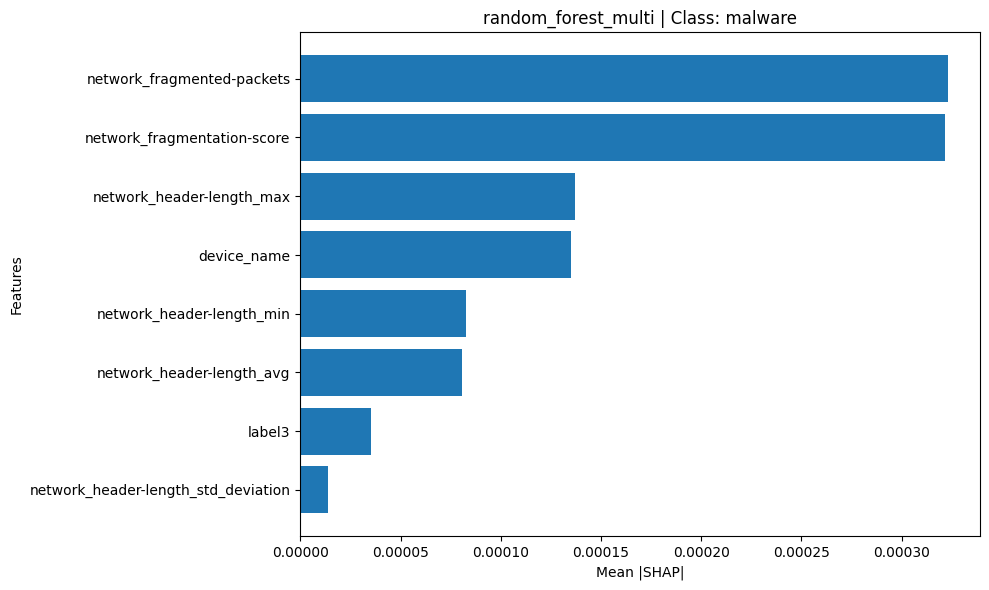

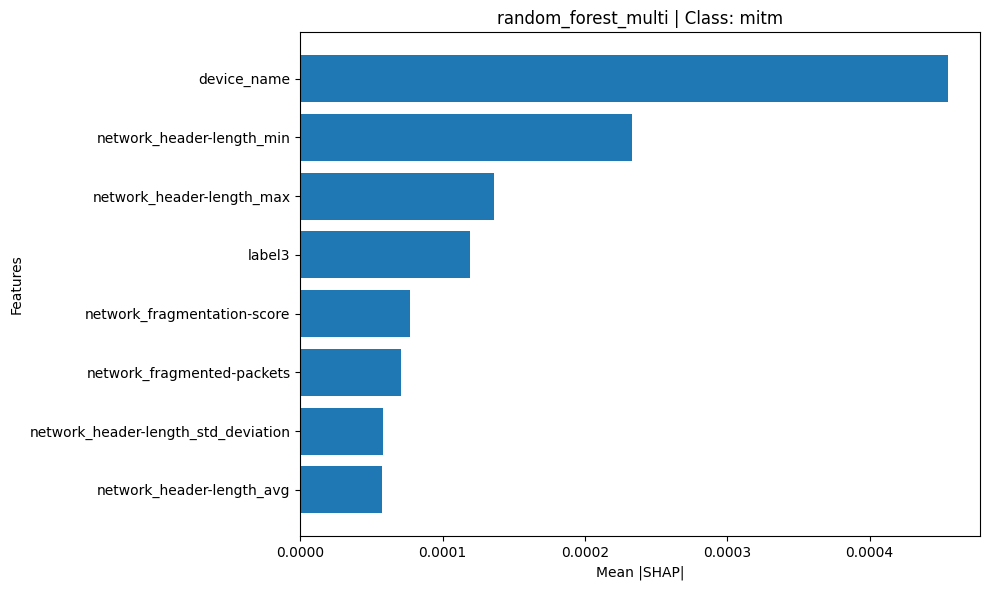

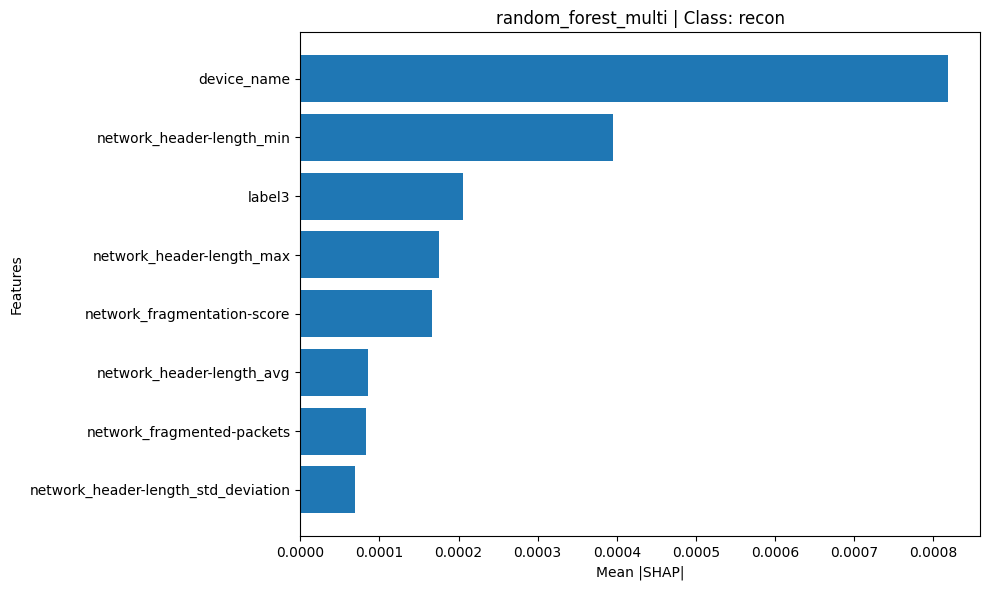

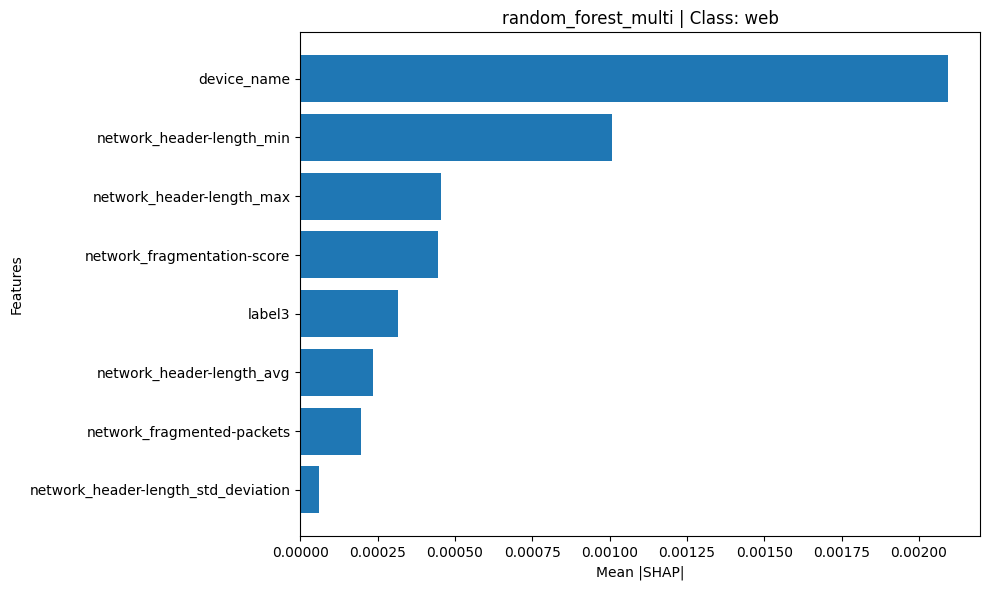



FIGURAS SALVAS
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\experiments\results_xai\figures


In [31]:

# GRÁFICOS ACADÊMICOS SHAP
#
# Gera:
#
# BINÁRIO
# - SHAP Global (3 modelos)
#
# MULTICLASSE
# - SHAP Global Macro (3 modelos)
# - SHAP por classe (micro)
#
# Salva automaticamente
#


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path


# DIRETÓRIO


FIG_DIR=(
    PROJECT_ROOT/
    "experiments"/
    "results_xai"/
    "figures"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TOP_N=15


# AUXILIAR


def normalize_multiclass(values,n_features,n_classes):

    values=np.array(values)

    if values.ndim==3:

        #(samples,features,classes)

        if values.shape[1]==n_features:

            values=np.transpose(
                values,
                (0,2,1)
            )

        #(classes,samples,features)

        elif values.shape[0]==n_classes:

            values=np.transpose(
                values,
                (1,0,2)
            )

    return values



# BINÁRIO - GLOBAL


print("\nGerando gráficos binários...")

sample=X_test.sample(
    min(
        300,
        len(X_test)
    ),
    random_state=42
)

for name,model in MODELS_BINARY.items():

    values,_=get_shap(
        model,
        sample,
        name
    )

    vals=reduce_shap(
        values
    )

    df=pd.DataFrame({

        "feature":
        X_test.columns[:len(vals)],

        "importance":
        vals

    })

    df=df.sort_values(

        "importance",
        ascending=False

    ).head(TOP_N)


    plt.figure(
        figsize=(10,6)
    )

    plt.barh(

        df.feature.iloc[::-1],
        df.importance.iloc[::-1]

    )

    plt.xlabel(
        "Mean |SHAP|"
    )

    plt.ylabel(
        "Features"
    )

    plt.title(
        f"Binary Global SHAP - {name}"
    )

    plt.tight_layout()

    plt.savefig(

        FIG_DIR/
        f"{name}_binary_global.png",

        dpi=300,
        bbox_inches="tight"

    )

    plt.show()

    plt.close()




# MULTICLASSE - GLOBAL MACRO


print(
    "\nGerando multiclass macro..."
)

for name,model in MODELS_MULTI.items():

    values,_=get_shap_multi(

        model,
        sample,
        name

    )

    values=np.array(
        values
    )

    pre,final_model=split_pipeline(
        model
    )

    classes=final_model.classes_

    n_classes=len(
        classes
    )

    n_features=len(
        X_test.columns
    )

    values=normalize_multiclass(

        values,
        n_features,
        n_classes

    )


    macro=np.mean(

        np.abs(values),

        axis=(0,1)

    )


    df=pd.DataFrame({

        "feature":
        X_test.columns[:len(macro)],

        "importance":
        macro

    })

    df=df.sort_values(

        "importance",
        ascending=False

    ).head(TOP_N)


    plt.figure(
        figsize=(10,6)
    )

    plt.barh(

        df.feature.iloc[::-1],
        df.importance.iloc[::-1]

    )

    plt.xlabel(
        "Mean |SHAP|"
    )

    plt.ylabel(
        "Features"
    )

    plt.title(
        f"Multiclass Macro SHAP - {name}"
    )

    plt.tight_layout()

    plt.savefig(

        FIG_DIR/
        f"{name}_multiclass_macro.png",

        dpi=300,
        bbox_inches="tight"

    )

    plt.show()

    plt.close()



# MULTICLASSE - MICRO (por classe)


print(
    "\nGerando SHAP por classe..."
)

for name,model in MODELS_MULTI.items():

    values,_=get_shap_multi(

        model,
        sample,
        name

    )

    values=np.array(
        values
    )

    pre,final_model=split_pipeline(
        model
    )

    classes=final_model.classes_

    n_classes=len(
        classes
    )

    n_features=len(
        X_test.columns
    )


    values=normalize_multiclass(

        values,
        n_features,
        n_classes

    )


    for i,cls in enumerate(
        classes
    ):

        class_values=np.mean(

            np.abs(
                values[:,i,:]
            ),

            axis=0

        )


        df=pd.DataFrame({

            "feature":
            X_test.columns[:len(class_values)],

            "importance":
            class_values

        })

        df=df.sort_values(

            "importance",
            ascending=False

        ).head(TOP_N)


        plt.figure(
            figsize=(10,6)
        )

        plt.barh(

            df.feature.iloc[::-1],
            df.importance.iloc[::-1]

        )

        plt.xlabel(
            "Mean |SHAP|"
        )

        plt.ylabel(
            "Features"
        )

        plt.title(

            f"{name} | Class: {cls}"

        )

        plt.tight_layout()

        plt.savefig(

            FIG_DIR/
            f"{name}_{cls}_micro.png",

            dpi=300,
            bbox_inches="tight"

        )

        plt.show()

        plt.close()



print("\n")
print("="*60)
print("FIGURAS SALVAS")
print("="*60)

print(FIG_DIR)

# 12. SALVA RESULTADOS

In [ ]:
# ======================================================================
# CORREÇÃO DA CÉLULA 12: ALINHAMENTO DE SHAP COM PIPELINE E EXPORTAÇÃO
# ======================================================================

print("="*60)
print("SALVANDO RESULTADOS XAI - CORRIGIDO")
print("="*60)

binary_fpfn = []
print("\n[PROCESSANDO CENÁRIO BINÁRIO]")

for name, model in MODELS_BINARY.items():
    print(f"Analisando impacto global: {name}")
    
    # 1. Extração robusta do Pipeline
    pre, final_model = split_pipeline(model)
    
    # 2. Alinhamento dinâmico dos nomes das features pós-transformação
    if pre is not None and hasattr(pre, "get_feature_names_out"):
        feature_names = list(pre.get_feature_names_out())
    else:
        feature_names = list(X_test.columns)
        
    # 3. Cálculo dos SHAP values
    values, X_trans = get_shap(model, sample, name)
    values = np.array(values)
    
    # 4. Tratamento de arrays multiclasse encapsulados em modelos binários
    if isinstance(values, list):
        values = values[1]
    elif values.ndim == 3:
        values = values[1] if values.shape[0] == 2 else values[0]
        
    # 5. Cálculo correto da importância global (Média do Absoluto)
    global_shap = np.mean(np.abs(values), axis=0)
    
    # Garantia de alinhamento estrito de dimensões
    n_features = min(len(feature_names), global_shap.shape[0])
    
    # Save SHAP Global
    pd.DataFrame({
        "feature": feature_names[:n_features],
        "importance": global_shap[:n_features]
    }).sort_values("importance", ascending=False).to_csv(
        SHAP_GLOBAL_DIR / f"{name}_binary_global.csv", index=False
    )
    
    # 6. Cálculo das Matrizes de Confusão para o log
    pred = model.predict(X_test)
    errors = pd.DataFrame({"real": y_test_binary, "pred": pred})
    
    TP = ((errors.real != "benign") & (errors.pred != "benign")).sum()
    FP = ((errors.real == "benign") & (errors.pred != "benign")).sum()
    FN = ((errors.real != "benign") & (errors.pred == "benign")).sum()
    
    binary_fpfn.append({"model": name, "TP": TP, "FP": FP, "FN": FN})

pd.DataFrame(binary_fpfn).to_csv(FPFN_BINARY_DIR / "fpfn_binary_models.csv", index=False)
print("[OK] Resultados binários salvos com sucesso.")

SALVANDO RESULTADOS XAI

BINÁRIO
Processando: logistic_regression
Processando: decision_tree
Processando: random_forest

MULTICLASSE
Processando: logistic_regression_multi
Processando: decision_tree_multi
Processando: random_forest_multi


SALVO COM SUCESSO
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\experiments\results_xai


# 13. GRÁFICOS SHAP

GERANDO FIGURAS

Gerando gráficos binários...
logistic_regression


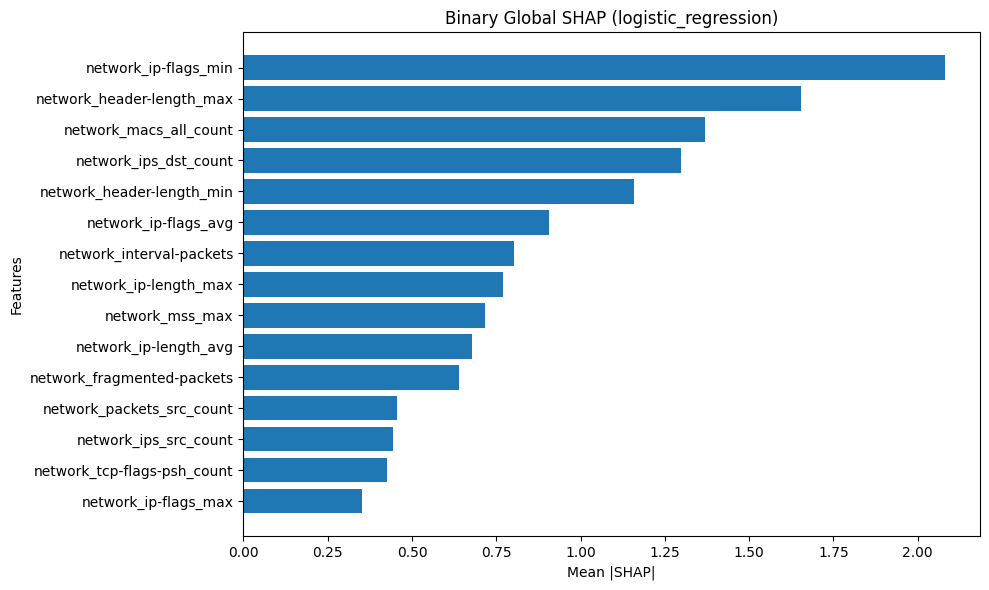

decision_tree


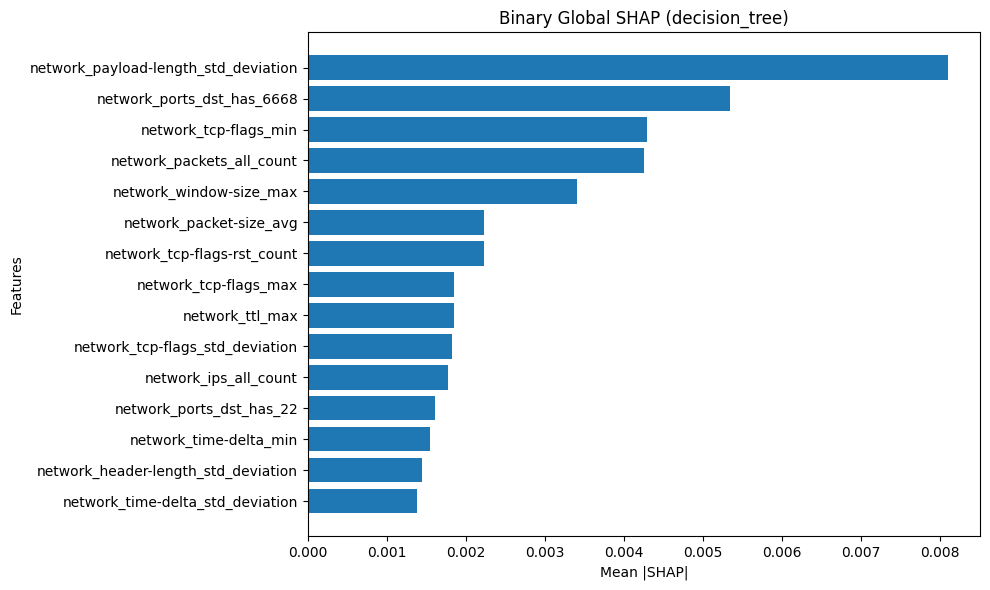

random_forest


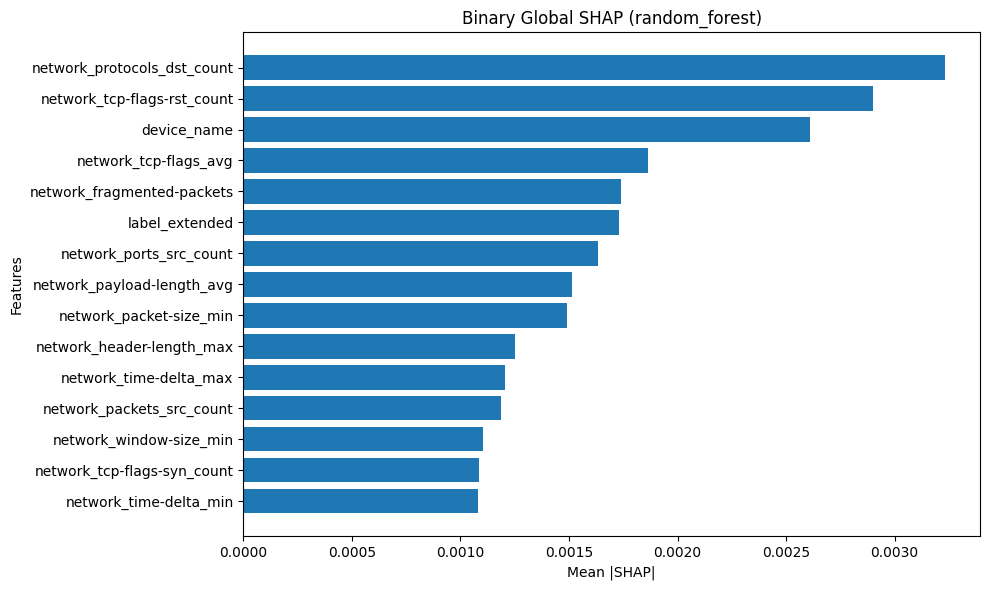


Gerando Macro SHAP...
logistic_regression_multi


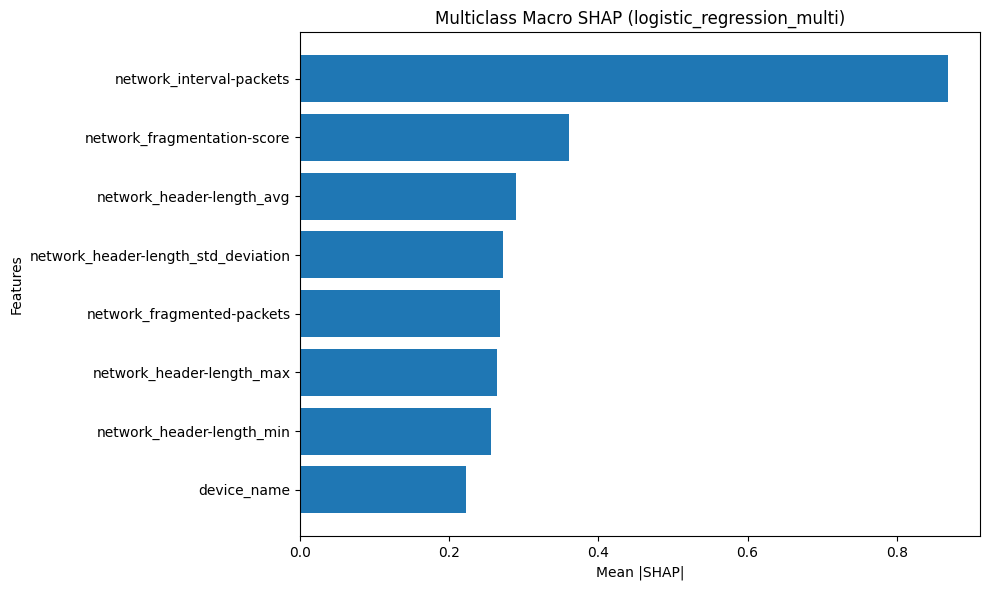

decision_tree_multi


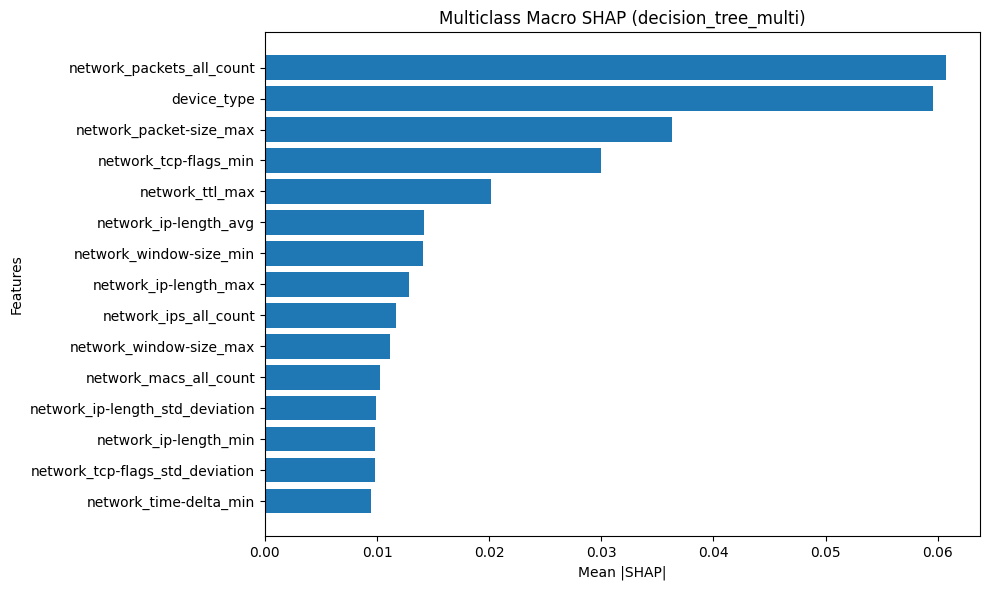

random_forest_multi


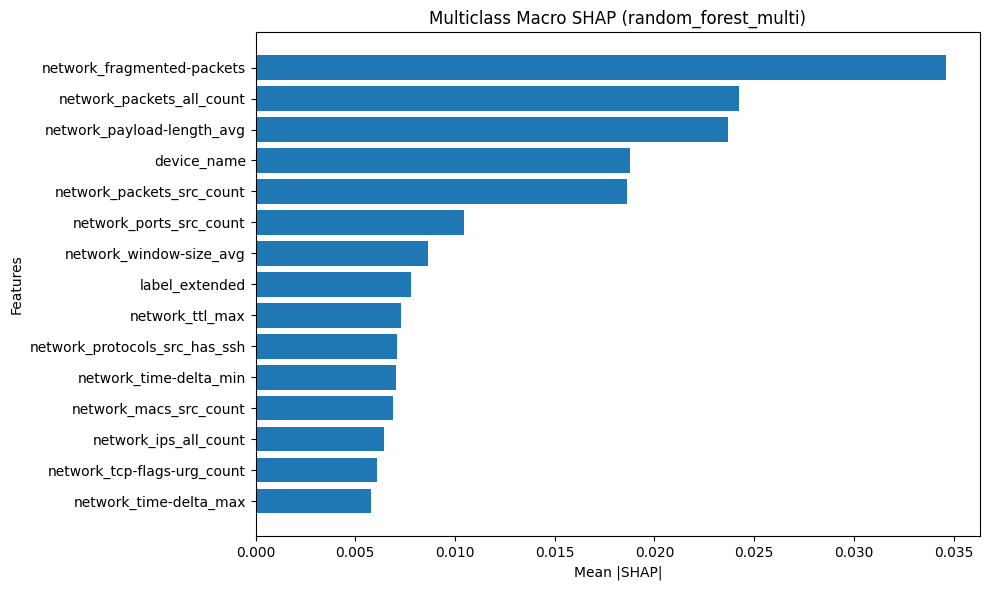


Gerando Micro SHAP...
logistic_regression_multi


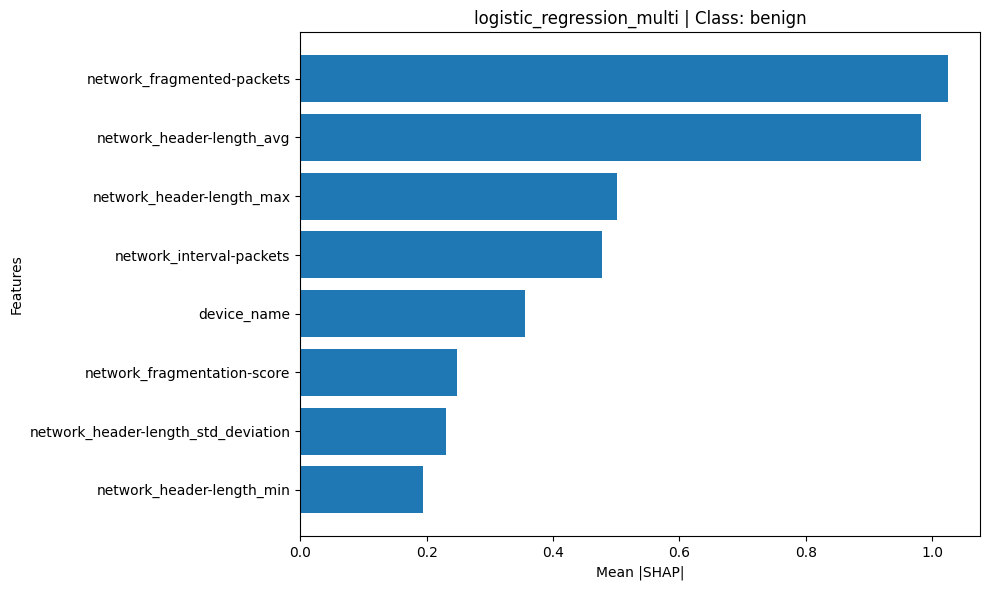

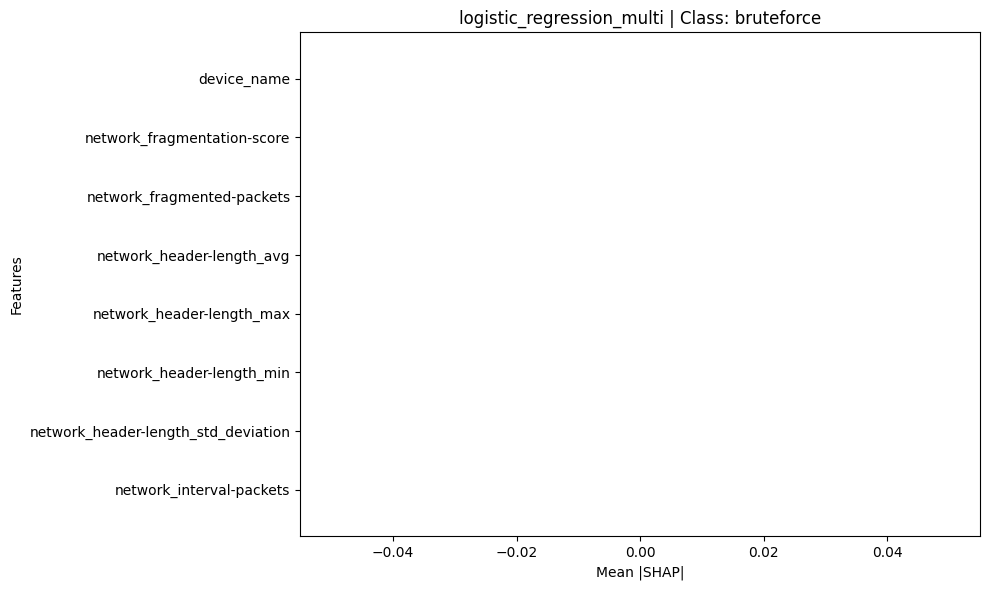

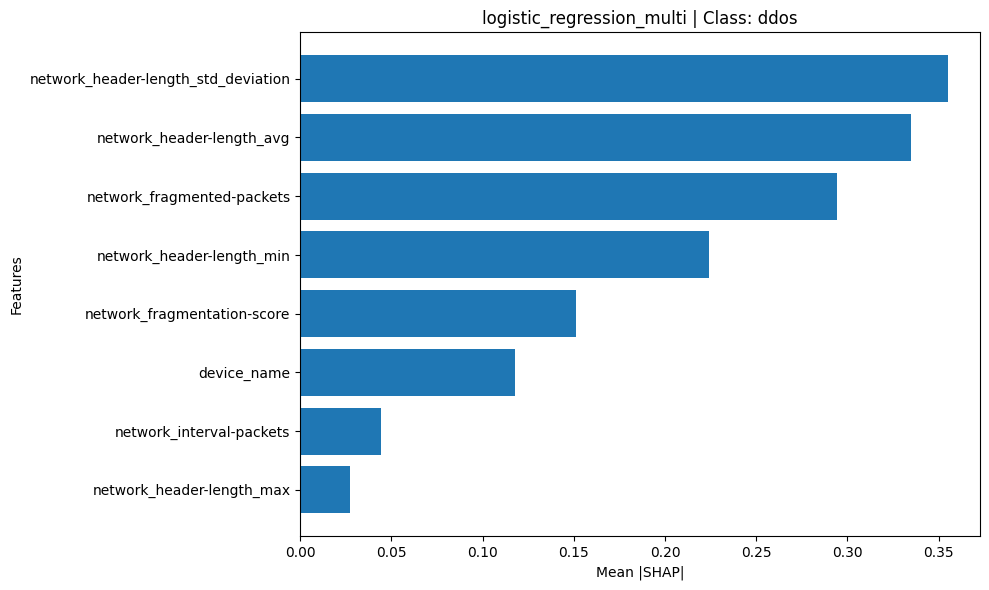

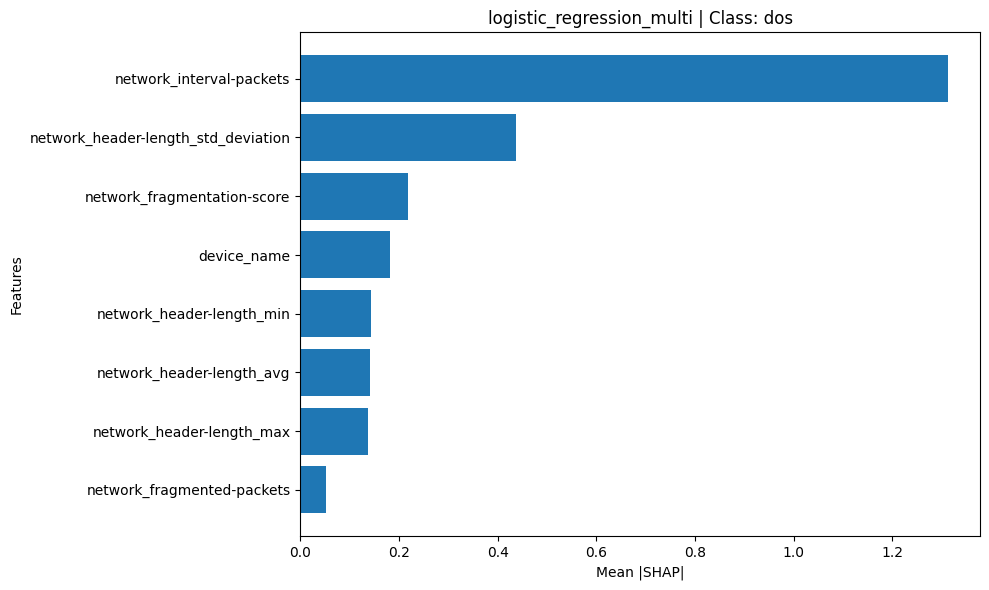

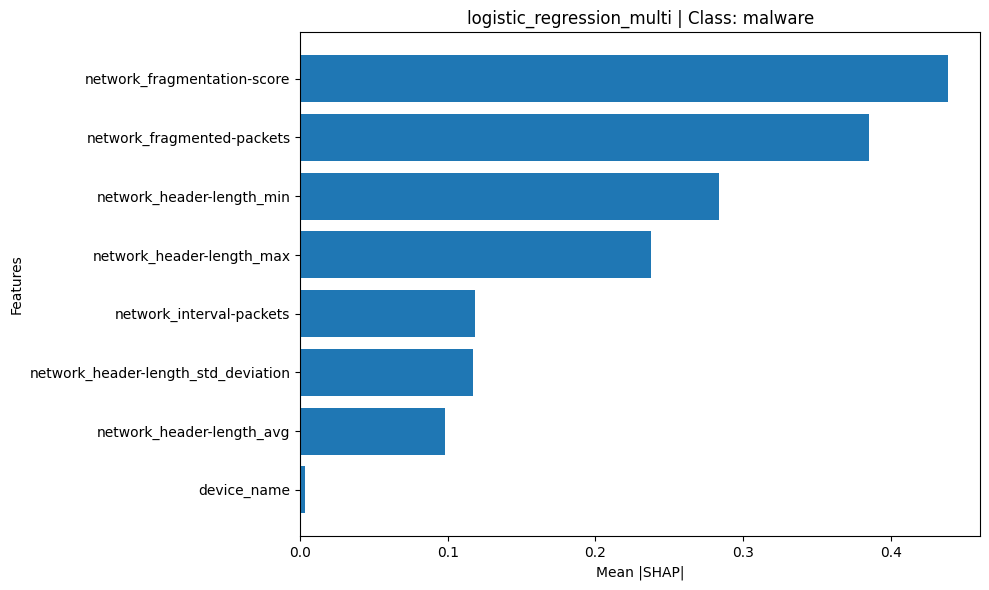

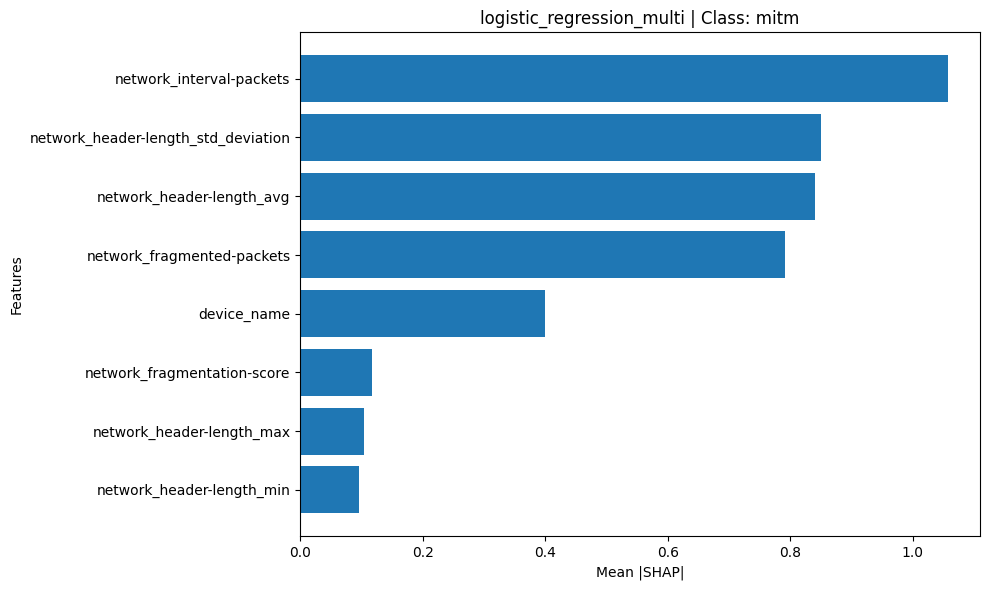

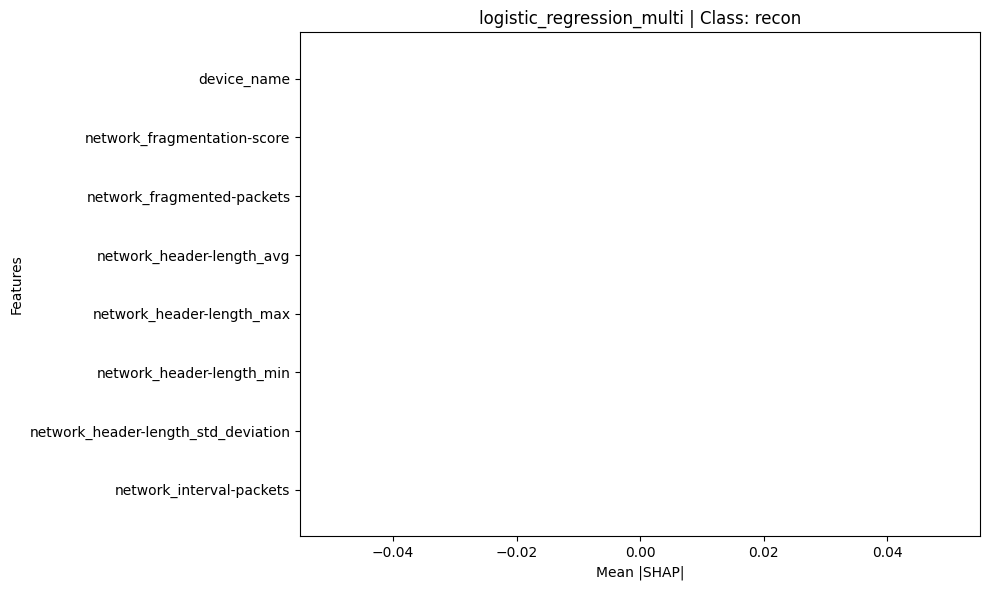

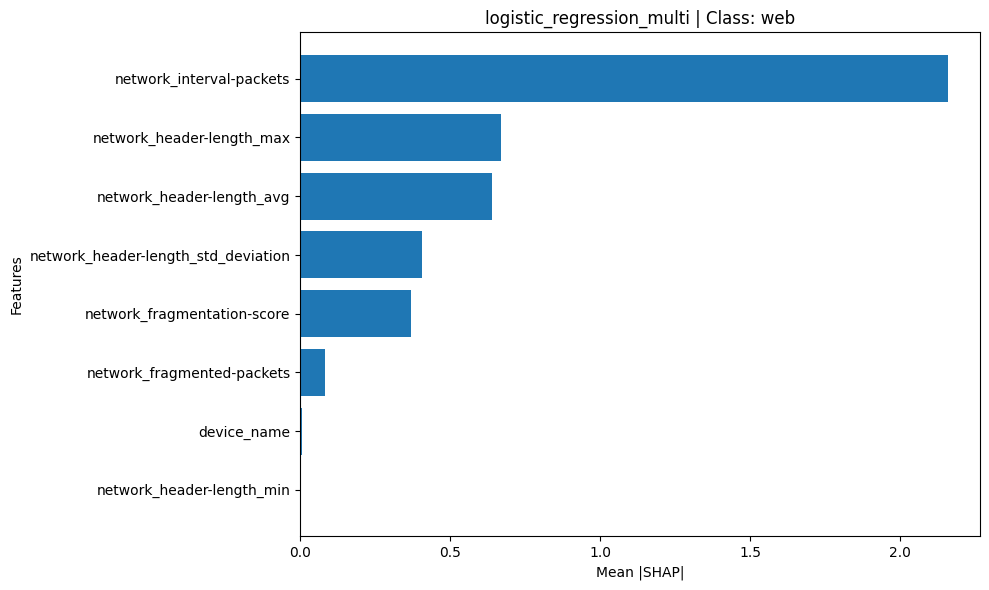

decision_tree_multi


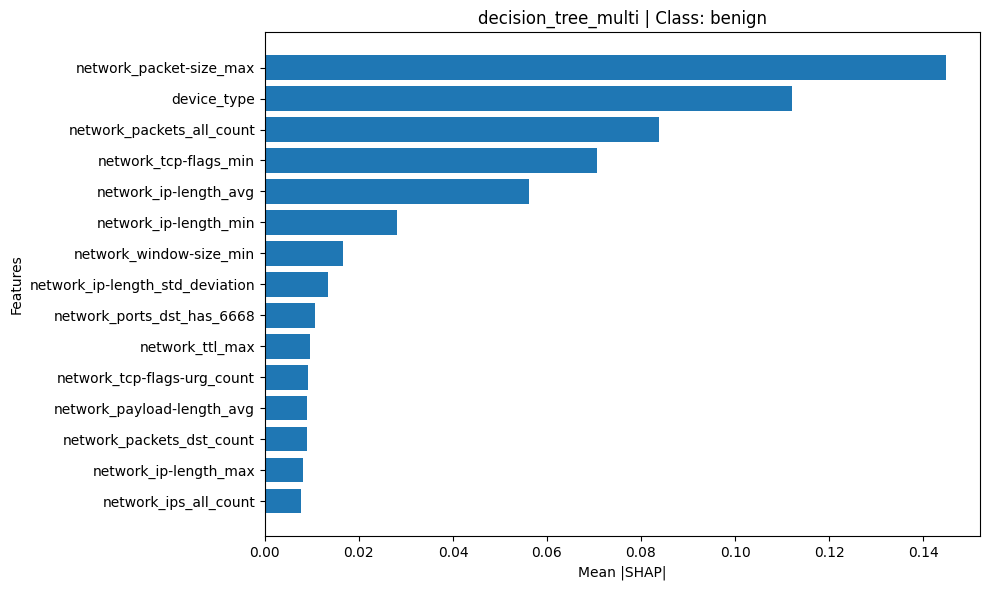

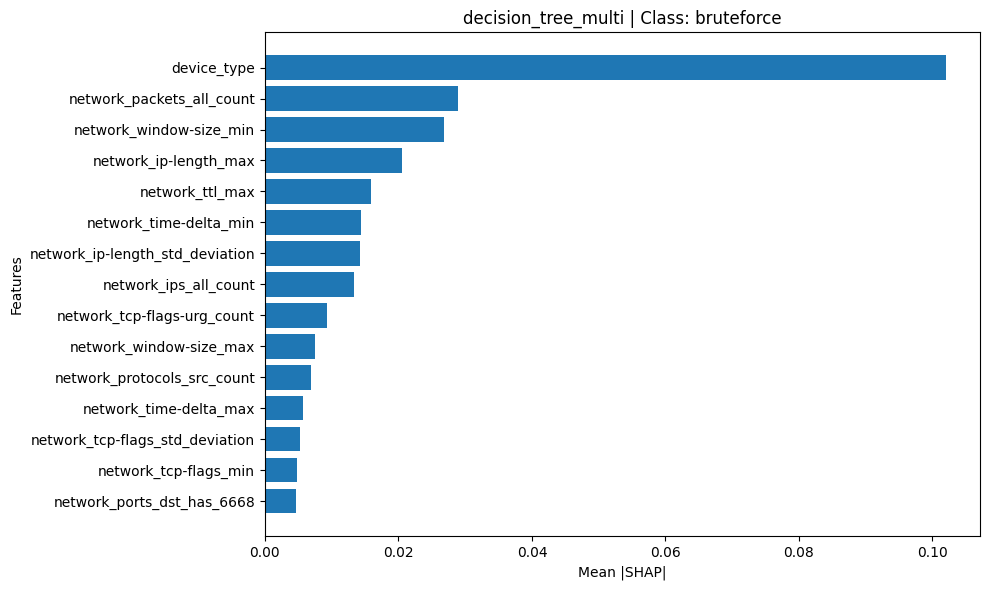

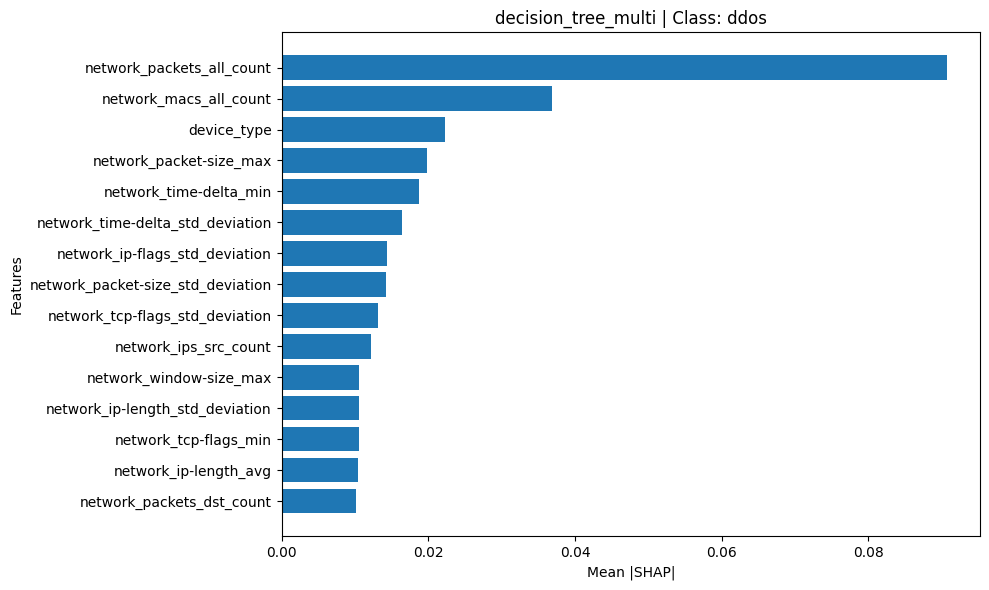

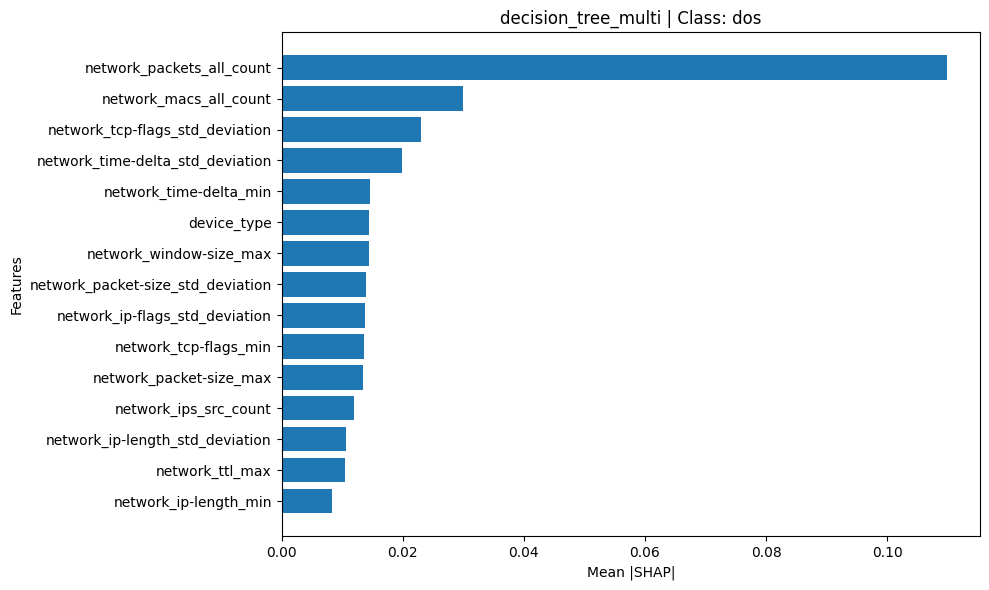

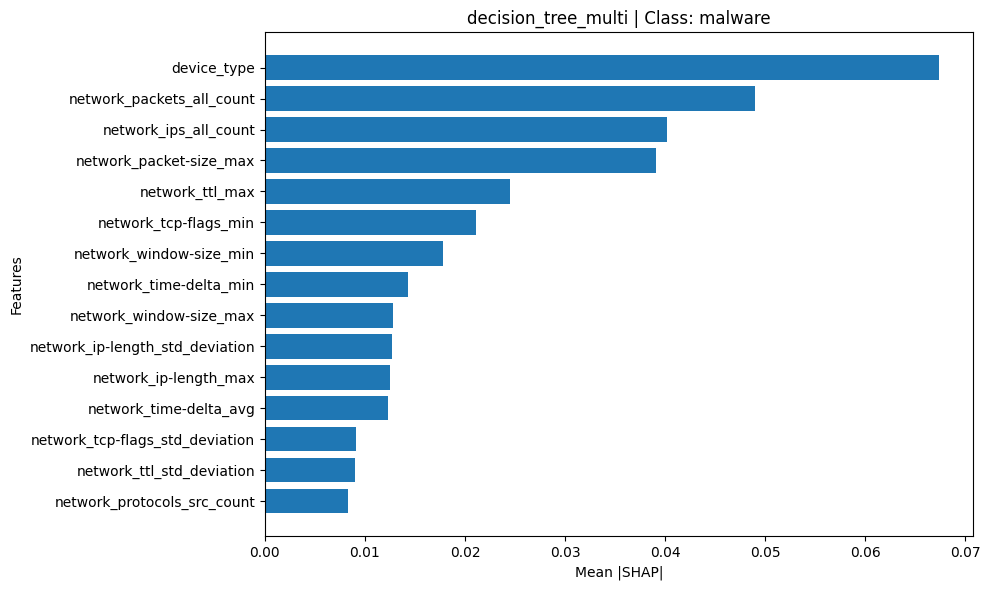

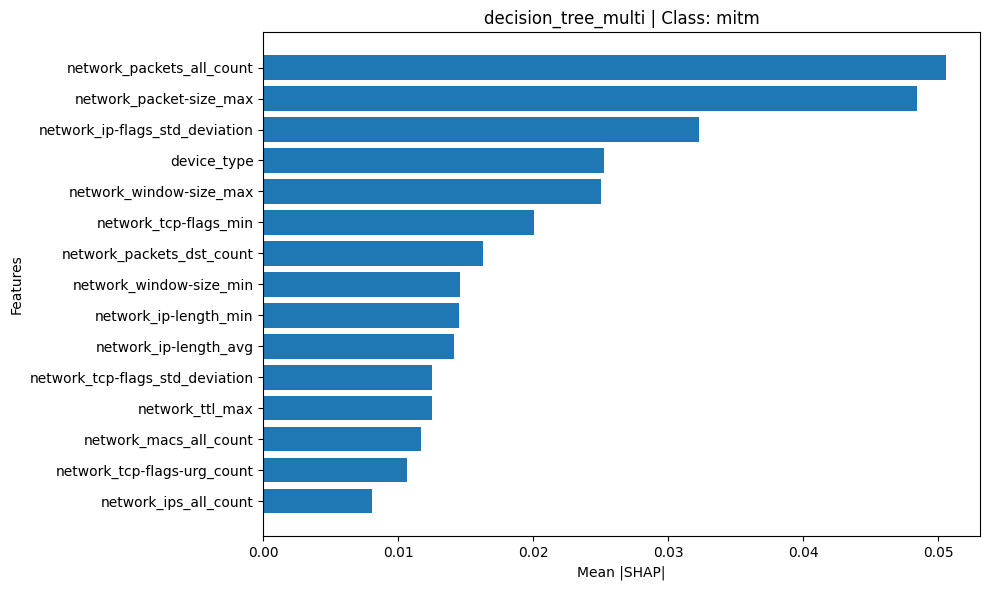

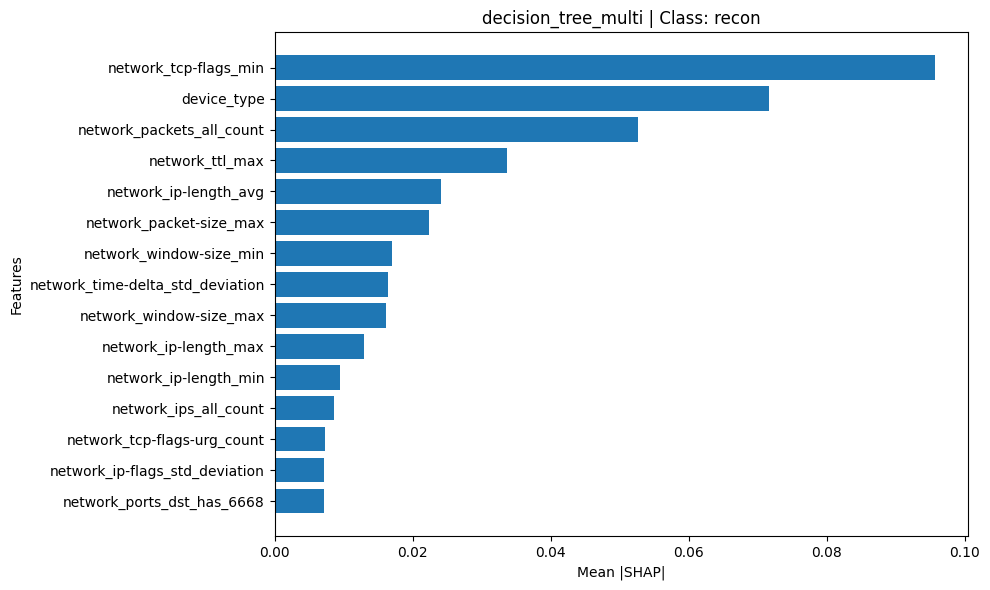

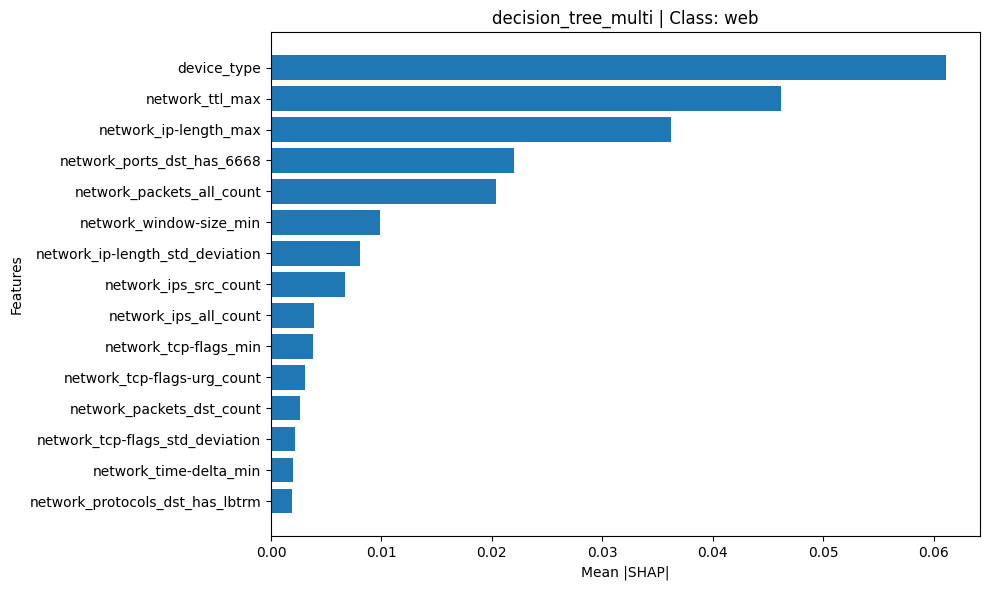

random_forest_multi


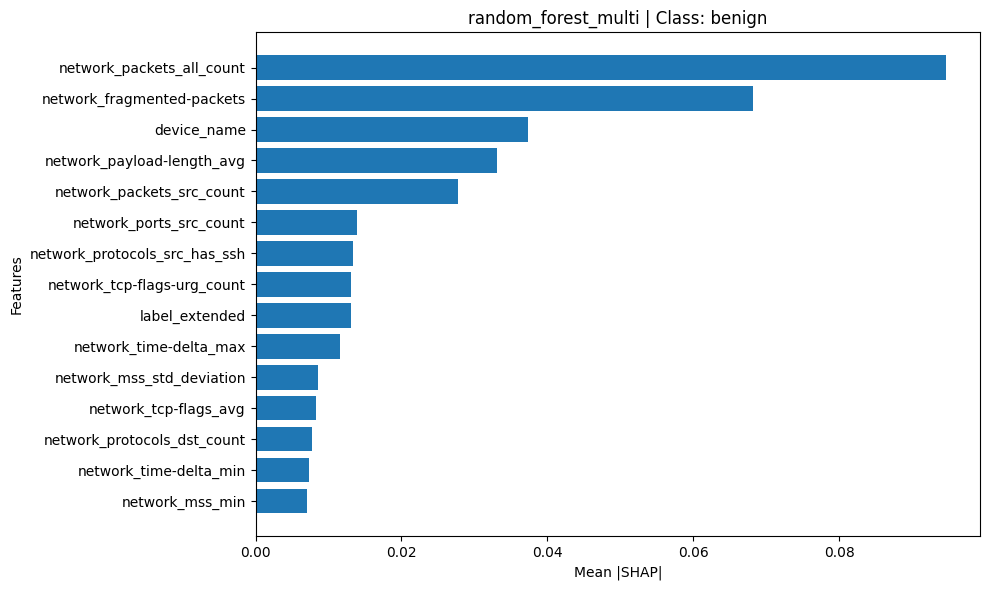

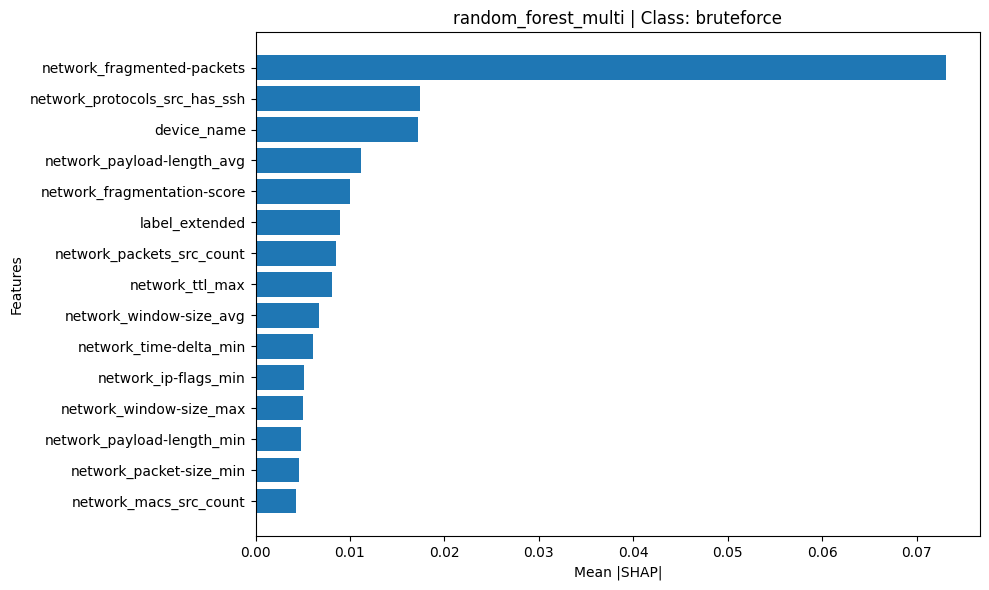

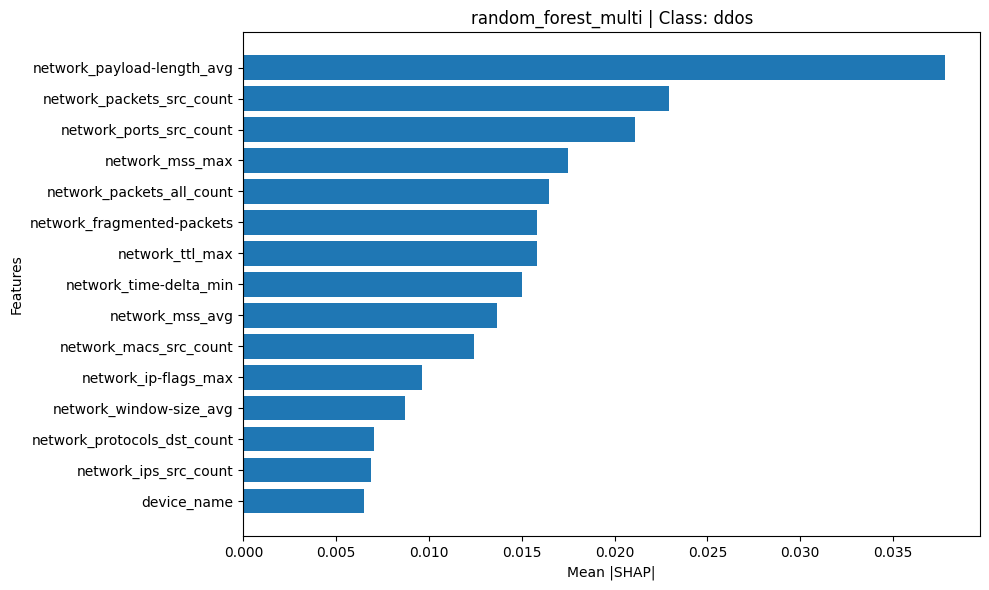

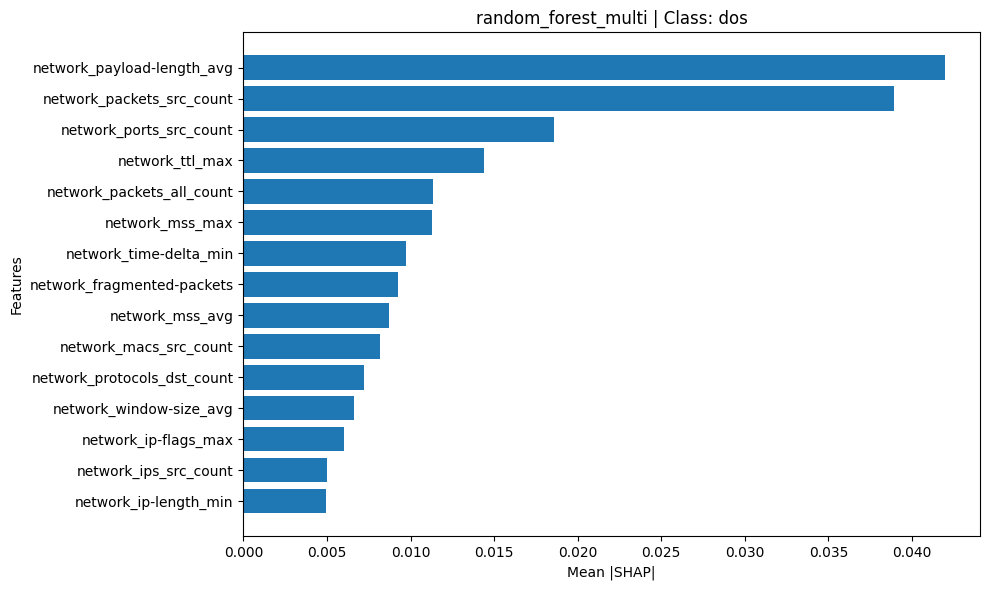

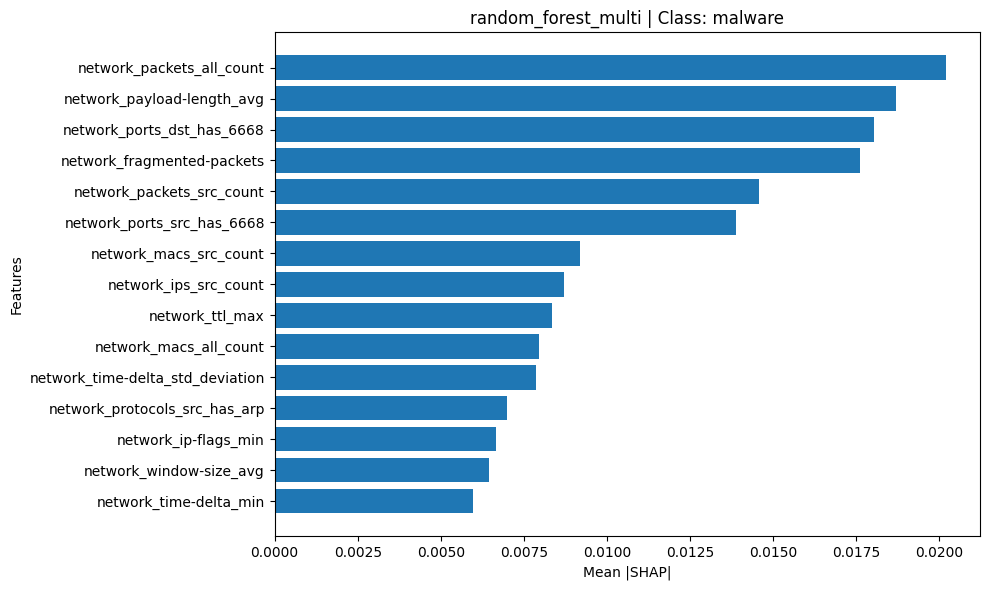

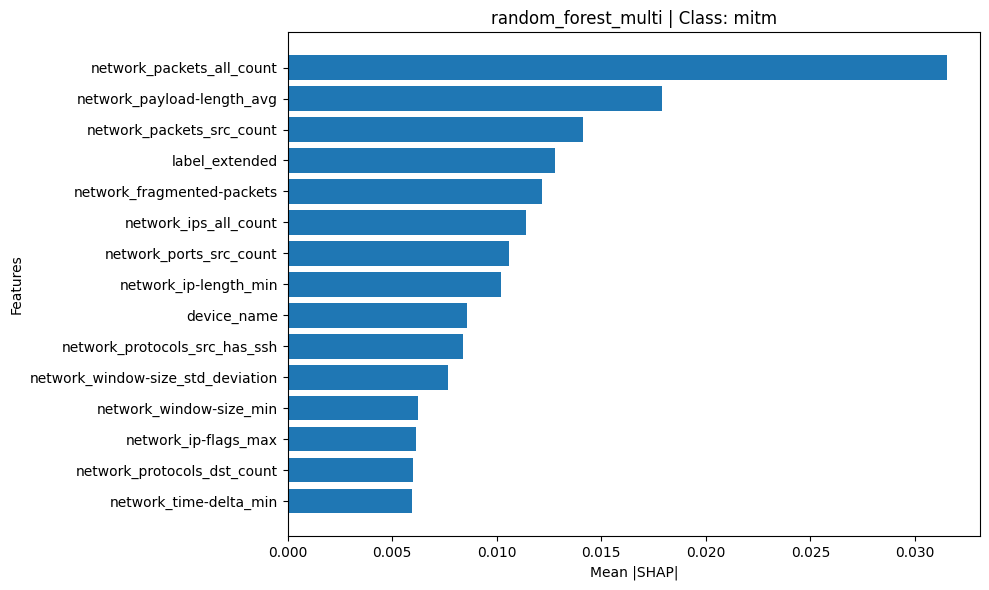

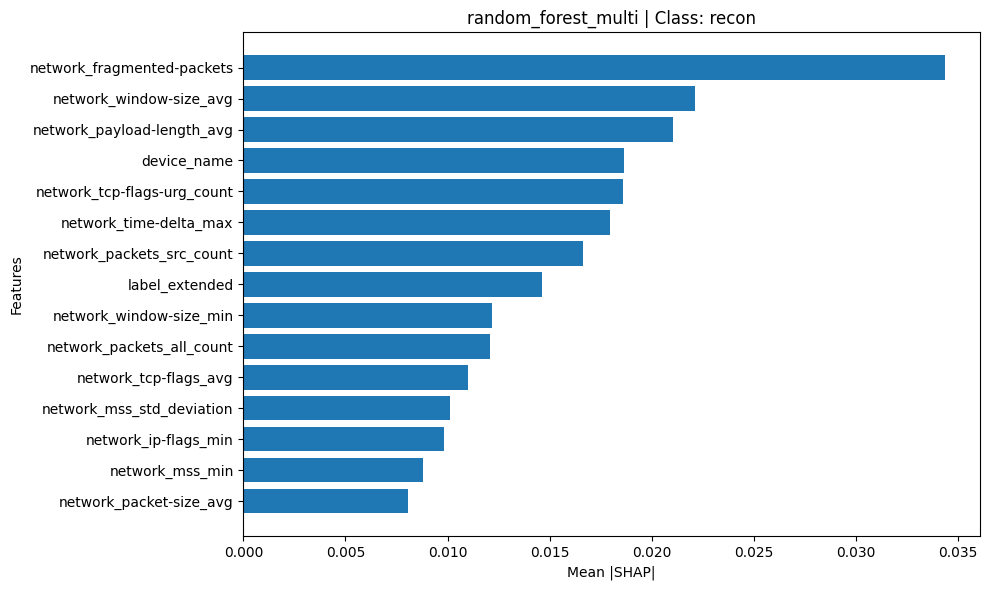

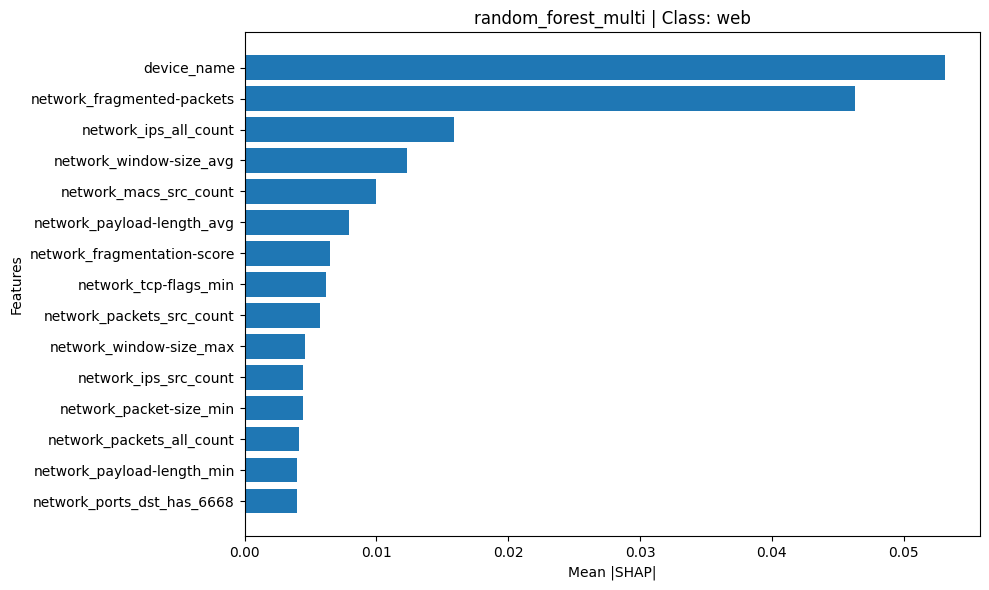



FIGURAS SALVAS
c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\experiments\results_xai\figures


In [33]:

# GRÁFICOS ACADÊMICOS SHAP


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


FIG_DIR=(

    PROJECT_ROOT/
    "experiments"/
    "results_xai"/
    "figures"

)

FIG_DIR.mkdir(

    parents=True,
    exist_ok=True

)

TOP_N=15



# AUXILIARES


def split_pipeline(model):

    try:

        pre=model[:-1]

        final=model[-1]

        return pre,final

    except:

        return None,model



def get_valid_features(model):

    try:

        pre=model.named_steps[
            "preprocessor"
        ]

        features=list(

            pre.get_feature_names_out()

        )

    except:

        features=list(
            X_test.columns
        )


    invalid=[

        "label1",
        "label2",
        "label3",
        "label4",
        "device"

    ]

    features=[

        f for f in features
        if f not in invalid

    ]

    return features



def normalize_shap(

    values,
    n_features,
    n_classes=None

):

    values=np.array(values)

    if values.ndim==3:

        #(samples,features,classes)

        if values.shape[1]==n_features:

            values=np.transpose(

                values,
                (0,2,1)

            )

        #(classes,samples,features)

        elif (

            n_classes is not None
            and
            values.shape[0]==n_classes

        ):

            values=np.transpose(

                values,
                (1,0,2)

            )

    return values



# AMOSTRA


sample=X_test.sample(

    min(
        300,
        len(X_test)
    ),

    random_state=42

)

print("="*60)
print("GERANDO FIGURAS")
print("="*60)



# BINÁRIO — SHAP GLOBAL


print("\nGerando gráficos binários...")


for name,model in MODELS_BINARY.items():

    print(name)

    features=get_valid_features(
        model
    )

    values,_=get_shap(

        model,
        sample,
        name

    )

    values=np.array(values)

    if values.ndim==3:

        global_shap=np.mean(

            np.abs(values),
            axis=(0,2)

        )

    else:

        global_shap=np.mean(

            np.abs(values),
            axis=0

        )


    n=min(

        len(features),
        len(global_shap)

    )

    df=pd.DataFrame({

        "feature":
        features[:n],

        "importance":
        global_shap[:n]

    })

    df=df.sort_values(

        "importance",
        ascending=False

    ).head(TOP_N)


    plt.figure(figsize=(10,6))

    plt.barh(

        df.feature.iloc[::-1],
        df.importance.iloc[::-1]

    )

    plt.xlabel("Mean |SHAP|")
    plt.ylabel("Features")

    plt.title(

        f"Binary Global SHAP ({name})"

    )

    plt.tight_layout()

    plt.savefig(

        FIG_DIR/
        f"{name}_binary_global.png",

        dpi=300,
        bbox_inches="tight"

    )

    plt.show()
    plt.close()




# MULTICLASSE — MACRO


print("\nGerando Macro SHAP...")


for name,model in MODELS_MULTI.items():

    print(name)

    features=get_valid_features(
        model
    )

    values,_=get_shap_multi(

        model,
        sample,
        name

    )


    _,final_model=split_pipeline(
        model
    )

    classes=final_model.classes_


    values=normalize_shap(

        values,
        len(features),
        len(classes)

    )


    macro=np.mean(

        np.abs(values),

        axis=(0,1)

    )


    n=min(

        len(features),
        len(macro)

    )


    df=pd.DataFrame({

        "feature":
        features[:n],

        "importance":
        macro[:n]

    })

    df=df.sort_values(

        "importance",
        ascending=False

    ).head(TOP_N)


    plt.figure(figsize=(10,6))

    plt.barh(

        df.feature.iloc[::-1],
        df.importance.iloc[::-1]

    )

    plt.xlabel("Mean |SHAP|")
    plt.ylabel("Features")

    plt.title(

        f"Multiclass Macro SHAP ({name})"

    )

    plt.tight_layout()

    plt.savefig(

        FIG_DIR/
        f"{name}_macro.png",

        dpi=300,
        bbox_inches="tight"

    )

    plt.show()
    plt.close()




# MULTICLASSE — MICRO


print("\nGerando Micro SHAP...")


for name,model in MODELS_MULTI.items():

    print(name)

    features=get_valid_features(
        model
    )

    values,_=get_shap_multi(

        model,
        sample,
        name

    )

    _,final_model=split_pipeline(
        model
    )

    classes=final_model.classes_


    values=normalize_shap(

        values,
        len(features),
        len(classes)

    )


    for i,cls in enumerate(classes):

        micro=np.mean(

            np.abs(
                values[:,i,:]
            ),

            axis=0

        )

        n=min(

            len(features),
            len(micro)

        )


        df=pd.DataFrame({

            "feature":
            features[:n],

            "importance":
            micro[:n]

        })

        df=df.sort_values(

            "importance",
            ascending=False

        ).head(TOP_N)


        plt.figure(figsize=(10,6))

        plt.barh(

            df.feature.iloc[::-1],
            df.importance.iloc[::-1]

        )

        plt.xlabel("Mean |SHAP|")
        plt.ylabel("Features")

        plt.title(

            f"{name} | Class: {cls}"

        )

        plt.tight_layout()

        plt.savefig(

            FIG_DIR/
            f"{name}_{cls}_micro.png",

            dpi=300,
            bbox_inches="tight"

        )

        plt.show()
        plt.close()



print("\n")
print("="*60)
print("FIGURAS SALVAS")
print("="*60)

print(FIG_DIR)